# MA5851 Assessment 3: WebCrawler and NLP System
## Task 3: Data Wrangling — Cleaning, Normalisation, Feature Extraction & EDA

**Issue:** Cost-of-Living Crisis in Australia — NLP Analysis of ABC News Articles  
**Data Source:** ABC News (`abc_articles.csv`) — 1,022 articles scraped across 6 topics × 12 locations  
**Objective:** Clean and normalise the corpus, extract NLP features, apply word embeddings, and visualise the data.

### 3.0 Library Imports

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import csv
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, FreqDist
from collections import Counter
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud
from datetime import datetime

# Download required NLTK data
for pkg in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger',
            'omw-1.4', 'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_theme(style='whitegrid', palette='muted')

### 3.1 Load Raw Data

In [2]:
df = pd.read_csv('abc_articles.csv')
print(f'Raw corpus shape : {df.shape}')
print(f'Columns          : {df.columns.tolist()}')
print(f'\nNull counts:')
print(df.isnull().sum())
df.head(3)

Raw corpus shape : (1022, 5)
Columns          : ['url', 'title', 'date', 'topics', 'content']

Null counts:
url          0
title        0
date         0
topics     203
content      0
dtype: int64


,url,title,date,topics,content
0,https://www.abc.net.au/news/2010-07-08/strong-...,VIDEO: Strong jobs market puts pressure on inf...,Thu 8 Jul 2010,NaN,Lateline Business Australia has one of the low...
1,https://www.abc.net.au/news/2008-04-23/fraser-...,Fraser still calling for interest rates halt,Wed 23 Apr 2008,"State and Territory Government, Unrest, Confli...",Queensland Treasurer Andrew Fraser says today'...
2,https://www.abc.net.au/news/2025-01-01/st-luci...,St Lucia apartment plans approved despite obje...,Tue 31 Dec 2024,"Urban Development and Planning, Unrest, Confli...",612 ABC Brisbane The body corporate for Jerdan...


### 3.2 Data Cleaning

The raw scraped text contains residual HTML artefacts, broadcast-style labels (e.g. `VIDEO:`, `AUDIO:`), boilerplate footer text, and inconsistent date formats. The steps below progressively strip these layers while preserving semantic content.

> **Design note — sentence count:** `sent_count` is computed on the original `content` column **before** any text cleaning. The cleaning pipeline removes punctuation (including periods), so applying `sent_tokenize` after cleaning would eliminate all sentence boundaries and yield a constant count of 1 for every article — an uninformative feature. Computing it on the raw text preserves genuine sentence structure.

#### 3.2.1 Structural / Metadata Cleaning

In [3]:
df_clean = df.copy()

# Fill missing values
df_clean['topics']  = df_clean['topics'].fillna('Unknown')
df_clean['title']   = df_clean['title'].fillna('').astype(str)
df_clean['content'] = df_clean['content'].fillna('').astype(str)

# Strip broadcast prefixes from titles
prefix_pattern = r'^(VIDEO|AUDIO|PHOTO|LIVE|BREAKING|UPDATED)\s*:\s*'
df_clean['title'] = df_clean['title'].str.replace(prefix_pattern, '', regex=True, case=False)

# Parse and standardise date column
def parse_date(date_str):
    """Attempt multiple date format parses; return NaT on failure."""
    if pd.isna(date_str) or not str(date_str).strip():
        return pd.NaT
    for fmt in ['%a %d %b %Y', '%a %-d %b %Y', '%B %d, %Y', '%d %B %Y', '%Y-%m-%d']:
        try:
            return datetime.strptime(str(date_str).strip(), fmt)
        except ValueError:
            continue
    return pd.NaT

df_clean['date_parsed'] = df_clean['date'].apply(parse_date)
df_clean['year']  = df_clean['date_parsed'].dt.year
df_clean['month'] = df_clean['date_parsed'].dt.month
print(f'Date parse success rate: {df_clean["date_parsed"].notna().mean()*100:.1f}%')
print(f'Year range: {int(df_clean["year"].min())} – {int(df_clean["year"].max())}')

Date parse success rate: 90.5%
Year range: 2003 – 2025


#### 3.2.2 Content Text Cleaning

In [4]:
# ABC-specific boilerplate phrases commonly found in scraped bodies
BOILERPLATE = [
    r'Posted\s+\w+\s+\d+\s+\w+\s+\d{4}',
    r'Updated\s+\w+\s+\d+\s+\w+\s+\d{4}',
    r'Share\s+this\s+article',
    r'More on this story',
    r'Related Stories?',
    r'Watch\s+ABC\s+News',
    r'Listen\s+to\s+ABC\s+News',
    r'ABC\s+News\s+Homepage',
    r'First\s+posted\s+',
    r'\d{3}\s+ABC\s+\w+',   # e.g. '612 ABC Brisbane'
    r'Lateline\s+Business',
    r'Four\s+Corners',
]

df_clean['sent_count'] = df_clean['content'].apply(lambda x: len(sent_tokenize(str(x))))

def clean_content(text):
    """Remove HTML artefacts, boilerplate, and normalise whitespace."""
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)                        # Remove HTML tags
    for pat in BOILERPLATE:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)      # Remove boilerplate
    text = re.sub(r'http\S+|www\.\S+', ' ', text)            # Remove URLs
    text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)             # Remove special chars
    text = re.sub(r'\s+', ' ', text)                           # Collapse whitespace
    return text.strip()

df_clean['content_clean'] = df_clean['content'].apply(clean_content)

# Content length metrics
df_clean['char_count'] = df_clean['content_clean'].str.len()
df_clean['word_count'] = df_clean['content_clean'].str.split().str.len()

# Drop articles too short to be meaningful (<50 words after cleaning)
before = len(df_clean)
df_clean = df_clean[df_clean['word_count'] >= 50].reset_index(drop=True)
print(f'Removed {before - len(df_clean)} short articles → corpus size: {len(df_clean)}')
print()
print('Content length statistics (sent_count reflects real sentence boundaries):')
df_clean[['word_count', 'sent_count', 'char_count']].describe().round(1)

Removed 77 short articles → corpus size: 945

Content length statistics (sent_count reflects real sentence boundaries):


,word_count,sent_count,char_count
count,945.0,945.0,945.0
mean,744.5,35.5,4284.2
std,662.2,34.0,3756.9
min,50.0,2.0,309.0
25%,221.0,10.0,1300.0
50%,722.0,34.0,4181.0
75%,1020.0,49.0,5912.0
max,8497.0,525.0,49065.0


#### 3.2.3 Duplicate & Near-Duplicate Detection

In [5]:
# Exact-URL duplicates
n_url_dups = df_clean.duplicated(subset='url').sum()
print(f'Exact URL duplicates : {n_url_dups}')

# Title-level near-duplicates
n_title_dups = df_clean.duplicated(subset='title', keep='first').sum()
print(f'Duplicate titles     : {n_title_dups}')

df_clean = df_clean.drop_duplicates(subset='url').reset_index(drop=True)
df_clean = df_clean.drop_duplicates(subset='title', keep='first').reset_index(drop=True)
print(f'Final corpus size    : {len(df_clean)} articles')

Exact URL duplicates : 0
Duplicate titles     : 15
Final corpus size    : 930 articles


### 3.3 Text Normalisation

Normalisation follows the standard NLP pipeline: **lowercasing → tokenisation → stopword removal → POS tagging → lemmatisation**. Lemmatisation (using WordNet) is preferred over stemming because it returns real dictionary words, essential for interpretable Word2Vec embeddings.

#### 3.3.1 Tokenisation & POS Tagging

In [6]:
from nltk.corpus import wordnet

STOP_WORDS = set(stopwords.words('english'))

# Add domain-specific stopwords that add no analytical value
CUSTOM_STOPS = {
    'said', 'say', 'says', 'told', 'also', 'would', 'could', 'one',
    'like', 'get', 'got', 'go', 'going', 'abc', 'news', 'australia',
    'australian', 'mr', 'ms', 'dr', 'per', 'cent', 'year', 'time'
}
STOP_WORDS.update(CUSTOM_STOPS)

lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()

def get_wordnet_pos(treebank_tag):
    """Map Penn Treebank POS tag to WordNet POS constant."""
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN  # default to noun

def normalise_text(text):
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    # Keep only alphabetic tokens longer than 2 chars, not stopwords
    tokens_filtered = [
        t for t in tokens
        if t.isalpha() and len(t) > 2 and t not in STOP_WORDS
    ]
    # POS tagging on filtered tokens
    pos_tags = pos_tag(tokens_filtered)
    # Lemmatise using POS context
    lemmas = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    # Stemming (parallel, for comparison / TF-IDF variant)
    stems = [stemmer.stem(t) for t in tokens_filtered]
    return tokens_filtered, ' '.join(lemmas), ' '.join(stems), pos_tags

results = df_clean['content_clean'].apply(normalise_text)
df_clean['tokens']      = results.apply(lambda x: x[0])
df_clean['lemmatised']  = results.apply(lambda x: x[1])
df_clean['stemmed']     = results.apply(lambda x: x[2])
df_clean['pos_tags']    = results.apply(lambda x: x[3])
df_clean['token_count'] = df_clean['tokens'].apply(len)

print(f'\nAverage tokens per article (after normalisation): {df_clean["token_count"].mean():.0f}')

# Preview
sample = df_clean.iloc[1]
print(f'\nSample title      : {sample["title"]}')
print(f'Raw tokens (first 10): {sample["tokens"][:10]}')
print(f'Lemmatised (first 15): {sample["lemmatised"].split()[:15]}')
print(f'POS tags (first 8)   : {sample["pos_tags"][:8]}')


Average tokens per article (after normalisation): 380

Sample title      : St Lucia apartment plans approved despite objections from nearby residents
Raw tokens (first 10): ['body', 'corporate', 'jerdanefield', 'towers', 'urged', 'residents', 'oppose', 'nearby', 'development', 'radio']
Lemmatised (first 15): ['body', 'corporate', 'jerdanefield', 'tower', 'urge', 'resident', 'oppose', 'nearby', 'development', 'radio', 'brisbane', 'kenji', 'sato', 'apartment', 'owner']
POS tags (first 8)   : [('body', 'NN'), ('corporate', 'JJ'), ('jerdanefield', 'NN'), ('towers', 'NNS'), ('urged', 'VBD'), ('residents', 'NNS'), ('oppose', 'VBP'), ('nearby', 'JJ')]


#### 3.3.2 Stemming vs Lemmatisation — Comparative Example

In [7]:
sample_words = ['housing', 'renting', 'prices', 'groceries', 'affordability',
                'inflating', 'energies', 'increases', 'struggling', 'payments']

sample_pos_tags = pos_tag(sample_words)
proper_lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in sample_pos_tags]

comparison = pd.DataFrame({
    'Original'            : sample_words,
    'POS (detected)'      : [t for _, t in sample_pos_tags],
    'Stemmed'             : [stemmer.stem(w) for w in sample_words],
    'Lemmatised (correct)': proper_lemmas
})
print('Stemming vs Lemmatisation — Domain Word Comparison (POS-aware)')
print('='*70)
print(comparison.to_string(index=False))

Stemming vs Lemmatisation — Domain Word Comparison (POS-aware)
     Original POS (detected) Stemmed Lemmatised (correct)
      housing             NN    hous              housing
      renting            VBG    rent                 rent
       prices            NNS   price                price
    groceries            NNS groceri              grocery
affordability            VBP  afford        affordability
    inflating            VBG  inflat              inflate
     energies            NNS  energi               energy
    increases            VBZ increas             increase
   struggling            VBG struggl             struggle
     payments            NNS payment              payment


### 3.4 Feature Extraction

Two complementary representations are computed:

1. **TF-IDF** (Term Frequency–Inverse Document Frequency) — sparse matrix used directly by machine learning classifiers. TF-IDF downweights common words across the corpus and upweights distinctive terms, making it well-suited for document-level classification (Sparck Jones, 1972).

2. **Word2Vec** (Neural word embeddings) — dense vectors that capture semantic similarity between words, enabling the model to generalise beyond exact term matching (Mikolov et al., 2013).

#### 3.4.1 TF-IDF Feature Matrix

In [8]:
# Build TF-IDF on lemmatised corpus
tfidf_vec = TfidfVectorizer(
    max_features = 5000,   # top 5000 terms by frequency
    ngram_range  = (1, 2), # unigrams + bigrams for richer features
    min_df       = 3,      # ignore terms in fewer than 3 docs
    max_df       = 0.90,   # ignore terms in >90% of docs (near-stopwords)
    sublinear_tf = True    # apply log normalisation to TF
)
tfidf_matrix  = tfidf_vec.fit_transform(df_clean['lemmatised'])
feature_names = tfidf_vec.get_feature_names_out()

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} features')
print(f'  → Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))*100:.2f}%')

# Store as dense dataframe for downstream use
tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix, columns=feature_names)

print('\nTop 15 TF-IDF terms (by mean score across corpus):')
mean_scores = pd.Series(
    tfidf_matrix.mean(axis=0).A1, index=feature_names
).sort_values(ascending=False).head(15)
print(mean_scores)

TF-IDF matrix shape : (930, 5000)
  → 930 documents × 5000 features
  → Sparsity: 95.49%

Top 15 TF-IDF terms (by mean score across corpus):
housing       0.028937
government    0.027937
people        0.027934
price         0.026875
home          0.025747
cost          0.024730
service       0.023844
state         0.023687
increase      0.023103
know          0.021768
new           0.021147
live          0.020327
make          0.020279
work          0.020050
find          0.019910
dtype: float64


#### 3.4.2 Word2Vec Word Embeddings

In [9]:
# Prepare tokenised sentences for Word2Vec
token_lists = df_clean['tokens'].tolist()

# Train Word2Vec (Skip-Gram architecture, sg=1)
w2v_model = Word2Vec(
    sentences   = token_lists,
    vector_size = 100,
    window      = 5,
    min_count   = 5,
    workers     = 4,
    sg          = 1,
    epochs      = 30,
    seed        = 42
)
print(f'Word2Vec vocabulary size : {len(w2v_model.wv)}')

# Semantic similarity examples
target_words = ['rent', 'inflation', 'housing', 'grocery', 'energy']
print('\nSemantic neighbours (Word2Vec most_similar):')
print('-'*50)
for word in target_words:
    if word in w2v_model.wv:
        neighbours = w2v_model.wv.most_similar(word, topn=5)
        print(f"  '{word}': {[w for w,_ in neighbours]}")

Word2Vec vocabulary size : 7583

Semantic neighbours (Word2Vec most_similar):
--------------------------------------------------
  'rent': ['rental', 'rents', 'seth', 'akshat', 'alix']
  'inflation': ['gauge', 'trimmed', 'rate', 'moderated', 'michele']
  'housing': ['affordable', 'social', 'accord', 'pavey', 'affordability']
  'grocery': ['inquiry', 'supermarket', 'supermarkets', 'retail', 'farmgate']
  'energy': ['renewable', 'electricity', 'bills', 'hydrogen', 'efficiency']


#### 3.4.3 Document-Level Word2Vec Vectors (Mean Pooling)

In [10]:
def document_vector(tokens, model, vec_size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(vec_size)

doc_vectors = np.vstack(
    df_clean['tokens'].apply(lambda t: document_vector(t, w2v_model))
)
print(f'Document embedding matrix shape: {doc_vectors.shape}')
print(f'  → {doc_vectors.shape[0]} documents × {doc_vectors.shape[1]} dimensions')
np.save('doc_vectors_w2v.npy', doc_vectors)
print('Saved doc_vectors_w2v.npy for Task 4.')

Document embedding matrix shape: (930, 100)
  → 930 documents × 100 dimensions
Saved doc_vectors_w2v.npy for Task 4.


#### 3.4.4 Label Encoding — Primary Topic

In [11]:
# Assign a primary search topic label based on URL keywords
TOPIC_MAP = {
    'cost-of-living'      : 'Cost of Living',
    'housing-affordability': 'Housing Affordability',
    'rent'                : 'Rent Increase',
    'grocery'             : 'Grocery Prices',
    'energy'              : 'Energy Bills',
    'inflation'           : 'Inflation',
}

CONTENT_KEYWORDS = {
    'Cost of Living'       : ['cost of living', 'cost-of-living', 'living expenses', 'cost pressure'],
    'Housing Affordability': ['housing affordab', 'home buyer', 'first home', 'property price'],
    'Rent Increase'        : ['rent increase', 'rental crisis', 'rental market', 'renters'],
    'Grocery Prices'       : ['grocery', 'supermarket', 'food price', 'woolworths', 'coles'],
    'Energy Bills'         : ['energy bill', 'electricity cost', 'power bill', 'gas price'],
    'Inflation'            : ['inflation', 'cpi', 'consumer price', 'interest rate'],
}

def assign_topic(row):
    url_lower     = str(row['url']).lower()
    content_lower = str(row['content_clean']).lower()
    for key, label in TOPIC_MAP.items():
        if key in url_lower:
            return label
    for label, kws in CONTENT_KEYWORDS.items():
        if any(kw in content_lower for kw in kws):
            return label
    return 'General'

df_clean['primary_topic'] = df_clean.apply(assign_topic, axis=1)
le = LabelEncoder()
df_clean['topic_label'] = le.fit_transform(df_clean['primary_topic'])

print('Topic distribution:')
print(df_clean['primary_topic'].value_counts())

Topic distribution:
primary_topic
Cost of Living           287
Housing Affordability    166
Rent Increase            135
General                  116
Inflation                101
Energy Bills              69
Grocery Prices            56
Name: count, dtype: int64


#### 3.4.5 Save Cleaned Dataset

In [12]:
save_cols = ['url', 'title', 'date', 'date_parsed', 'year', 'month',
             'topics', 'primary_topic', 'topic_label',
             'content_clean', 'lemmatised', 'stemmed',
             'word_count', 'token_count', 'sent_count', 'char_count']

df_clean[save_cols].to_csv(
    'abc_articles_cleaned.csv',
    index    = False,
    encoding = 'utf-8-sig',
    quoting  = csv.QUOTE_ALL
)
print(f'Saved abc_articles_cleaned.csv ({len(df_clean)} rows)')

import joblib
joblib.dump(tfidf_vec, 'tfidf_vectoriser.joblib')
w2v_model.save('word2vec_model.bin')
print('Saved tfidf_vectoriser.joblib and word2vec_model.bin')

Saved abc_articles_cleaned.csv (930 rows)
Saved tfidf_vectoriser.joblib and word2vec_model.bin


### 3.5 Exploratory Data Analysis (EDA) & Visualisation

The following visualisations characterise the corpus across five dimensions: temporal distribution, document-length distribution, topic composition, vocabulary frequency, and semantic embedding space.

#### 3.5.1 Corpus Descriptive Statistics

In [13]:
stats = df_clean[['word_count', 'token_count', 'sent_count', 'char_count']].describe().round(1)
stats.columns = ['Word Count', 'Token Count (norm.)', 'Sentence Count', 'Character Count']
print('Corpus Descriptive Statistics')
print('='*70)
print(stats.to_string())
print()
print('Note: Sentence Count reflects genuine sentence boundaries')
print('      (computed on raw content before punctuation removal).')

Corpus Descriptive Statistics
       Word Count  Token Count (norm.)  Sentence Count  Character Count
count       930.0                930.0           930.0            930.0
mean        753.4                380.1            35.9           4335.4
std         663.6                328.8            34.1           3764.7
min          50.0                 30.0             2.0            309.0
25%         232.0                125.2            10.0           1389.2
50%         730.0                371.5            35.0           4227.5
75%        1028.0                525.0            49.0           5959.2
max        8497.0               4302.0           525.0          49065.0

Note: Sentence Count reflects genuine sentence boundaries
      (computed on raw content before punctuation removal).


#### 3.5.2 Article Length Distribution

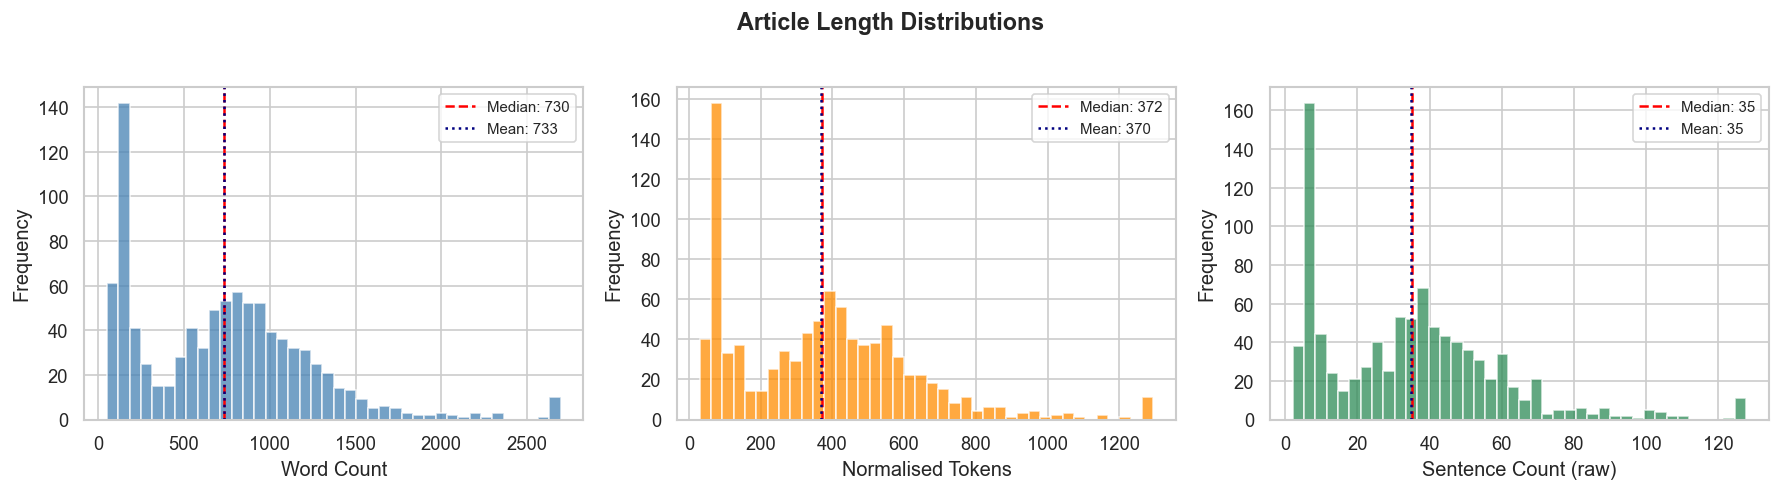

Figure 1: Article length distributions — word count and token count show right-skewed
distributions, typical of news corpora. Sentence count (computed on raw content)
now shows realistic variation rather than the erroneous constant of 1.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Article Length Distributions', fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('word_count',  'Word Count',           'steelblue'),
    ('token_count', 'Normalised Tokens',     'darkorange'),
    ('sent_count',  'Sentence Count (raw)',  'seagreen'),
]
for ax, (col, label, color) in zip(axes, metrics):
    data = df_clean[col].clip(upper=df_clean[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='red',  linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.axvline(data.mean(),   color='navy', linestyle=':',  linewidth=1.5,
               label=f'Mean: {data.mean():.0f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_length_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 1: Article length distributions — word count and token count show right-skewed\n'
      'distributions, typical of news corpora. Sentence count (computed on raw content)\n'
      'now shows realistic variation rather than the erroneous constant of 1.')

#### 3.5.3 Temporal Distribution of Articles

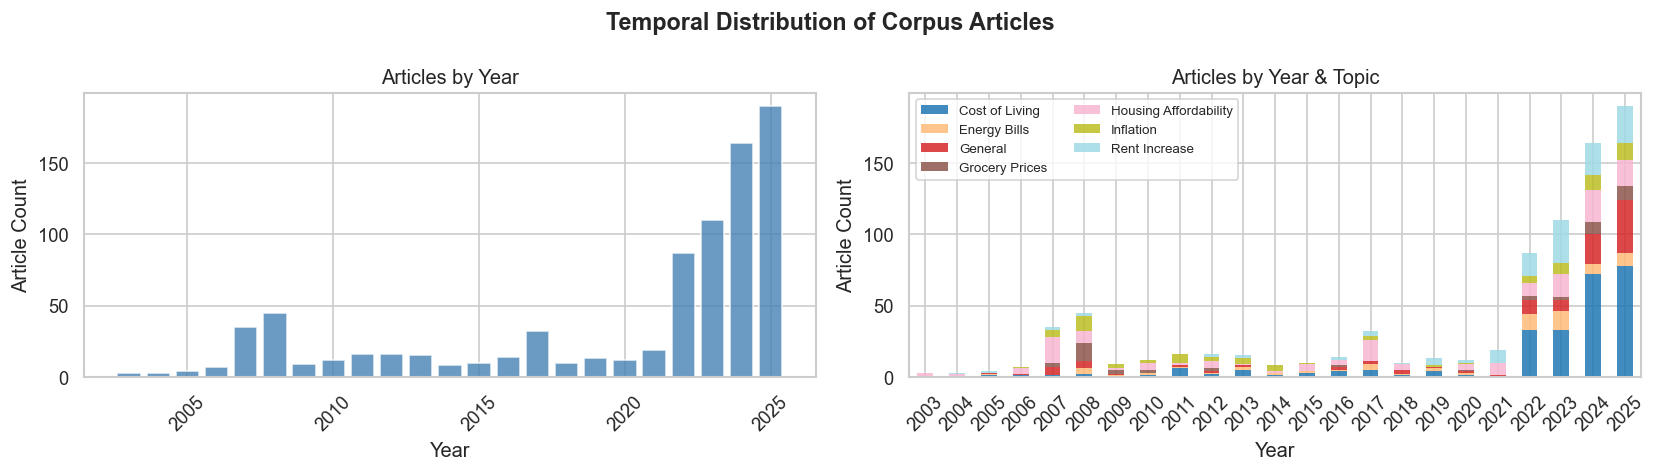

Figure 2: Temporal distribution — coverage peaks in 2022–2024, coinciding with heightened
Australian cost-of-living public debate. Older articles (pre-2015) are sparse.


In [15]:
df_dated = df_clean[df_clean['year'].notna()].copy()
df_dated['year'] = df_dated['year'].astype(int)
year_counts = df_dated['year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Temporal Distribution of Corpus Articles', fontsize=14, fontweight='bold')

axes[0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Article Count')
axes[0].set_title('Articles by Year'); axes[0].tick_params(axis='x', rotation=45)

topic_year = df_dated.groupby(['year', 'primary_topic']).size().unstack(fill_value=0)
topic_year.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', edgecolor='none', alpha=0.85)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Article Count')
axes[1].set_title('Articles by Year & Topic')
axes[1].legend(fontsize=8, loc='upper left', ncol=2); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig2_temporal_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 2: Temporal distribution — coverage peaks in 2022–2024, coinciding with heightened\n'
      'Australian cost-of-living public debate. Older articles (pre-2015) are sparse.')

#### 3.5.4 Topic Distribution (Primary Label)

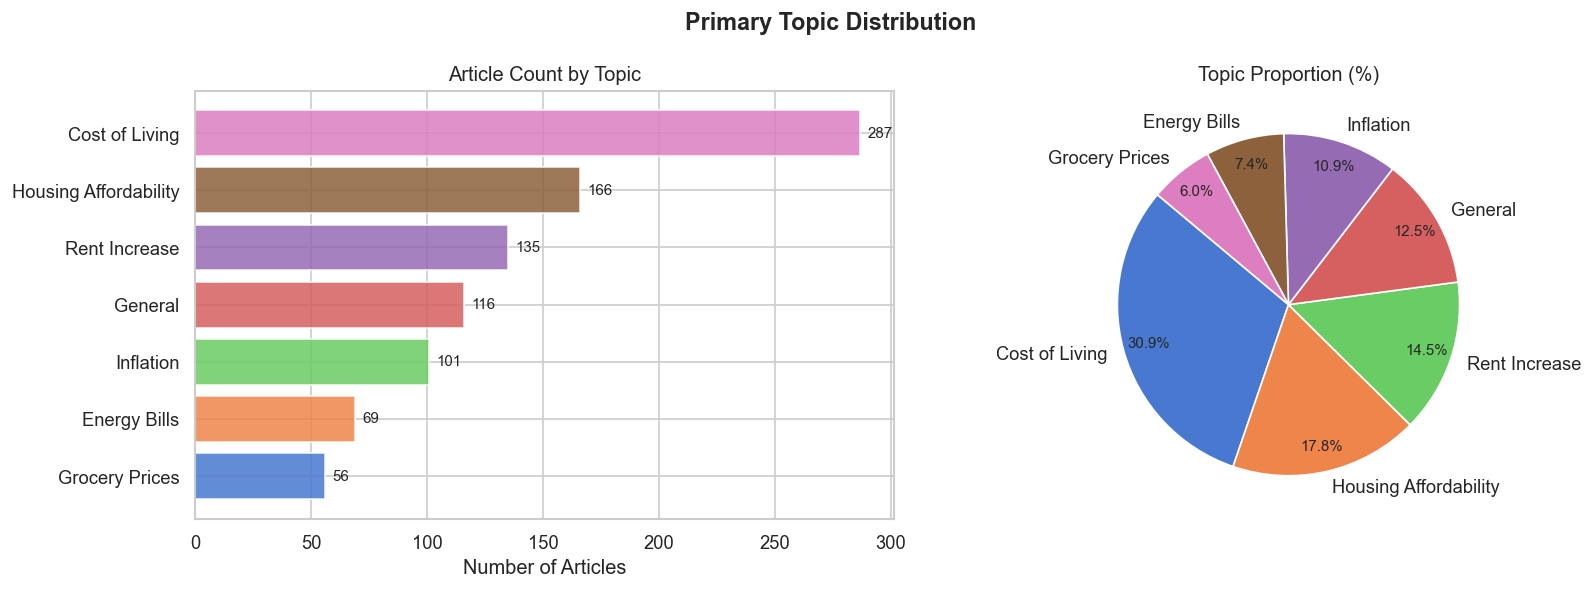

Figure 3: Topic distribution — Cost of Living dominates the corpus,
reflecting ABC News editorial prioritisation. Energy Bills is underrepresented,
which constitutes a sampling bias to be acknowledged in Task 4 evaluation.


In [16]:
topic_counts = df_clean['primary_topic'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Primary Topic Distribution', fontsize=14, fontweight='bold')
colors = sns.color_palette('muted', len(topic_counts))

axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Number of Articles'); axes[0].set_title('Article Count by Topic')
for i, (val, label) in enumerate(zip(topic_counts.values[::-1], topic_counts.index[::-1])):
    axes[0].text(val + 3, i, str(val), va='center', fontsize=9)

wedges, texts, autotexts = axes[1].pie(
    topic_counts.values, labels=topic_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=140, pctdistance=0.85
)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title('Topic Proportion (%)')

plt.tight_layout()
plt.savefig('fig3_topic_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 3: Topic distribution — Cost of Living dominates the corpus,\n'
      'reflecting ABC News editorial prioritisation. Energy Bills is underrepresented,\n'
      'which constitutes a sampling bias to be acknowledged in Task 4 evaluation.')

#### 3.5.5 Top-N Word Frequency Analysis

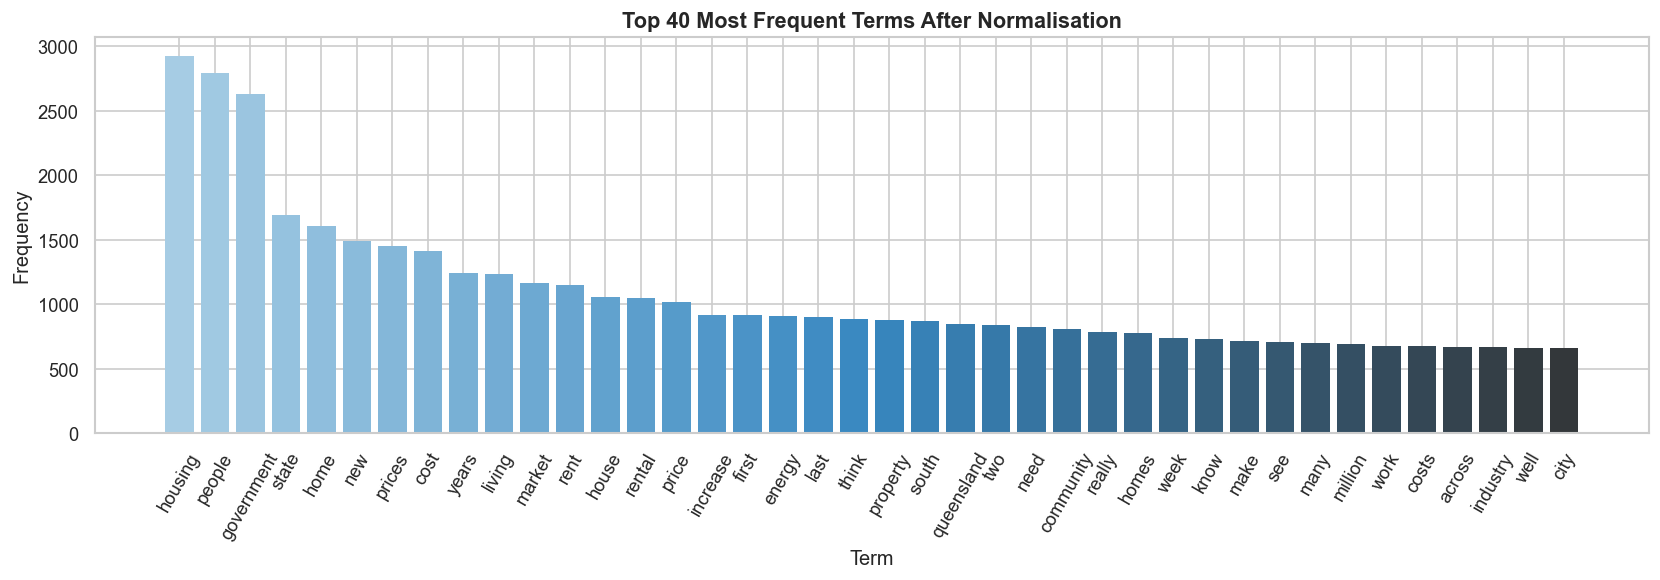

Total vocabulary size (after normalisation): 19,335
Total token count: 43,402


In [17]:
all_tokens = [token for tokens in df_clean['tokens'] for token in tokens]
freq_dist = FreqDist(all_tokens)
top_40 = freq_dist.most_common(40)
words, freqs = zip(*top_40)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(words, freqs, color=sns.color_palette('Blues_d', len(words)), edgecolor='none')
ax.set_title('Top 40 Most Frequent Terms After Normalisation', fontsize=13, fontweight='bold')
ax.set_xlabel('Term'); ax.set_ylabel('Frequency'); ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig('fig4_top_terms.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Total vocabulary size (after normalisation): {len(freq_dist):,}')
print(f'Total token count: {sum(freqs):,}')

#### 3.5.6 Word Cloud — Full Corpus

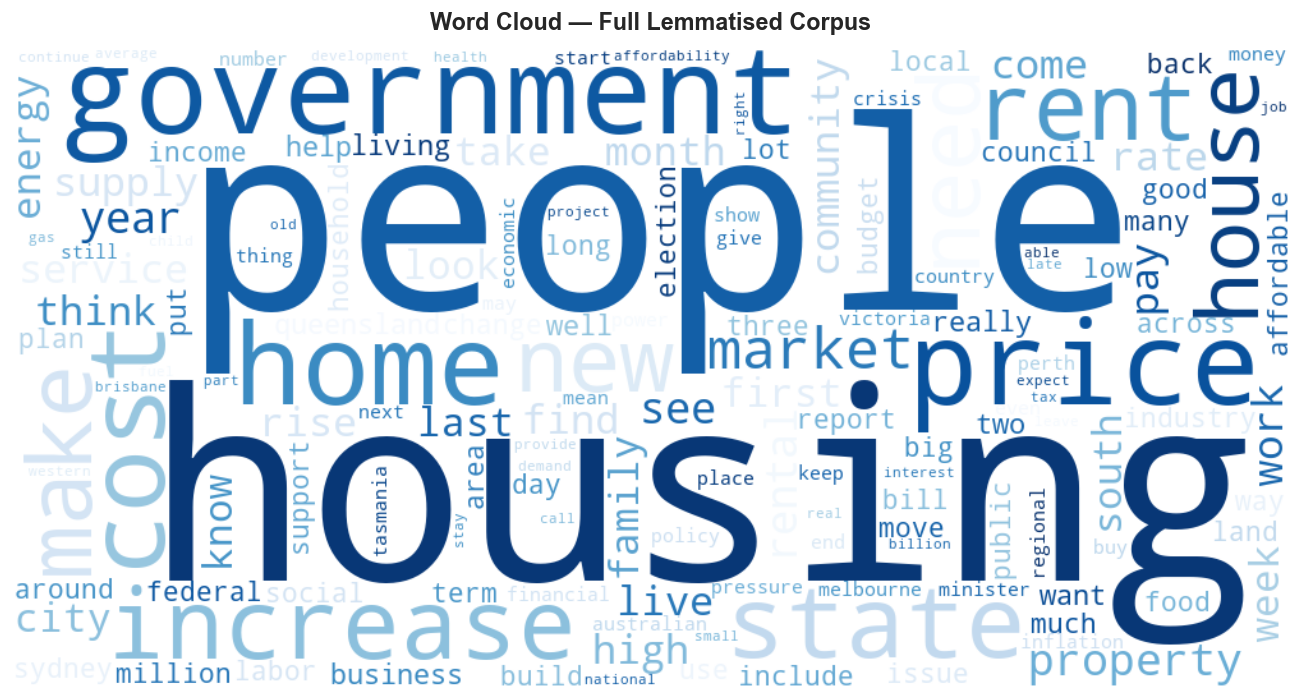

Figure 5: Word cloud highlights dominant discourse terms: rent, price, housing, cost, pay, market.


In [18]:
corpus_text = ' '.join(df_clean['lemmatised'])
wc = WordCloud(width=1000, height=500, background_color='white',
               colormap='Blues', max_words=150, collocations=False).generate(corpus_text)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title('Word Cloud — Full Lemmatised Corpus', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig5_wordcloud_corpus.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 5: Word cloud highlights dominant discourse terms: rent, price, housing, cost, pay, market.')

#### 3.5.7 Word Clouds by Topic

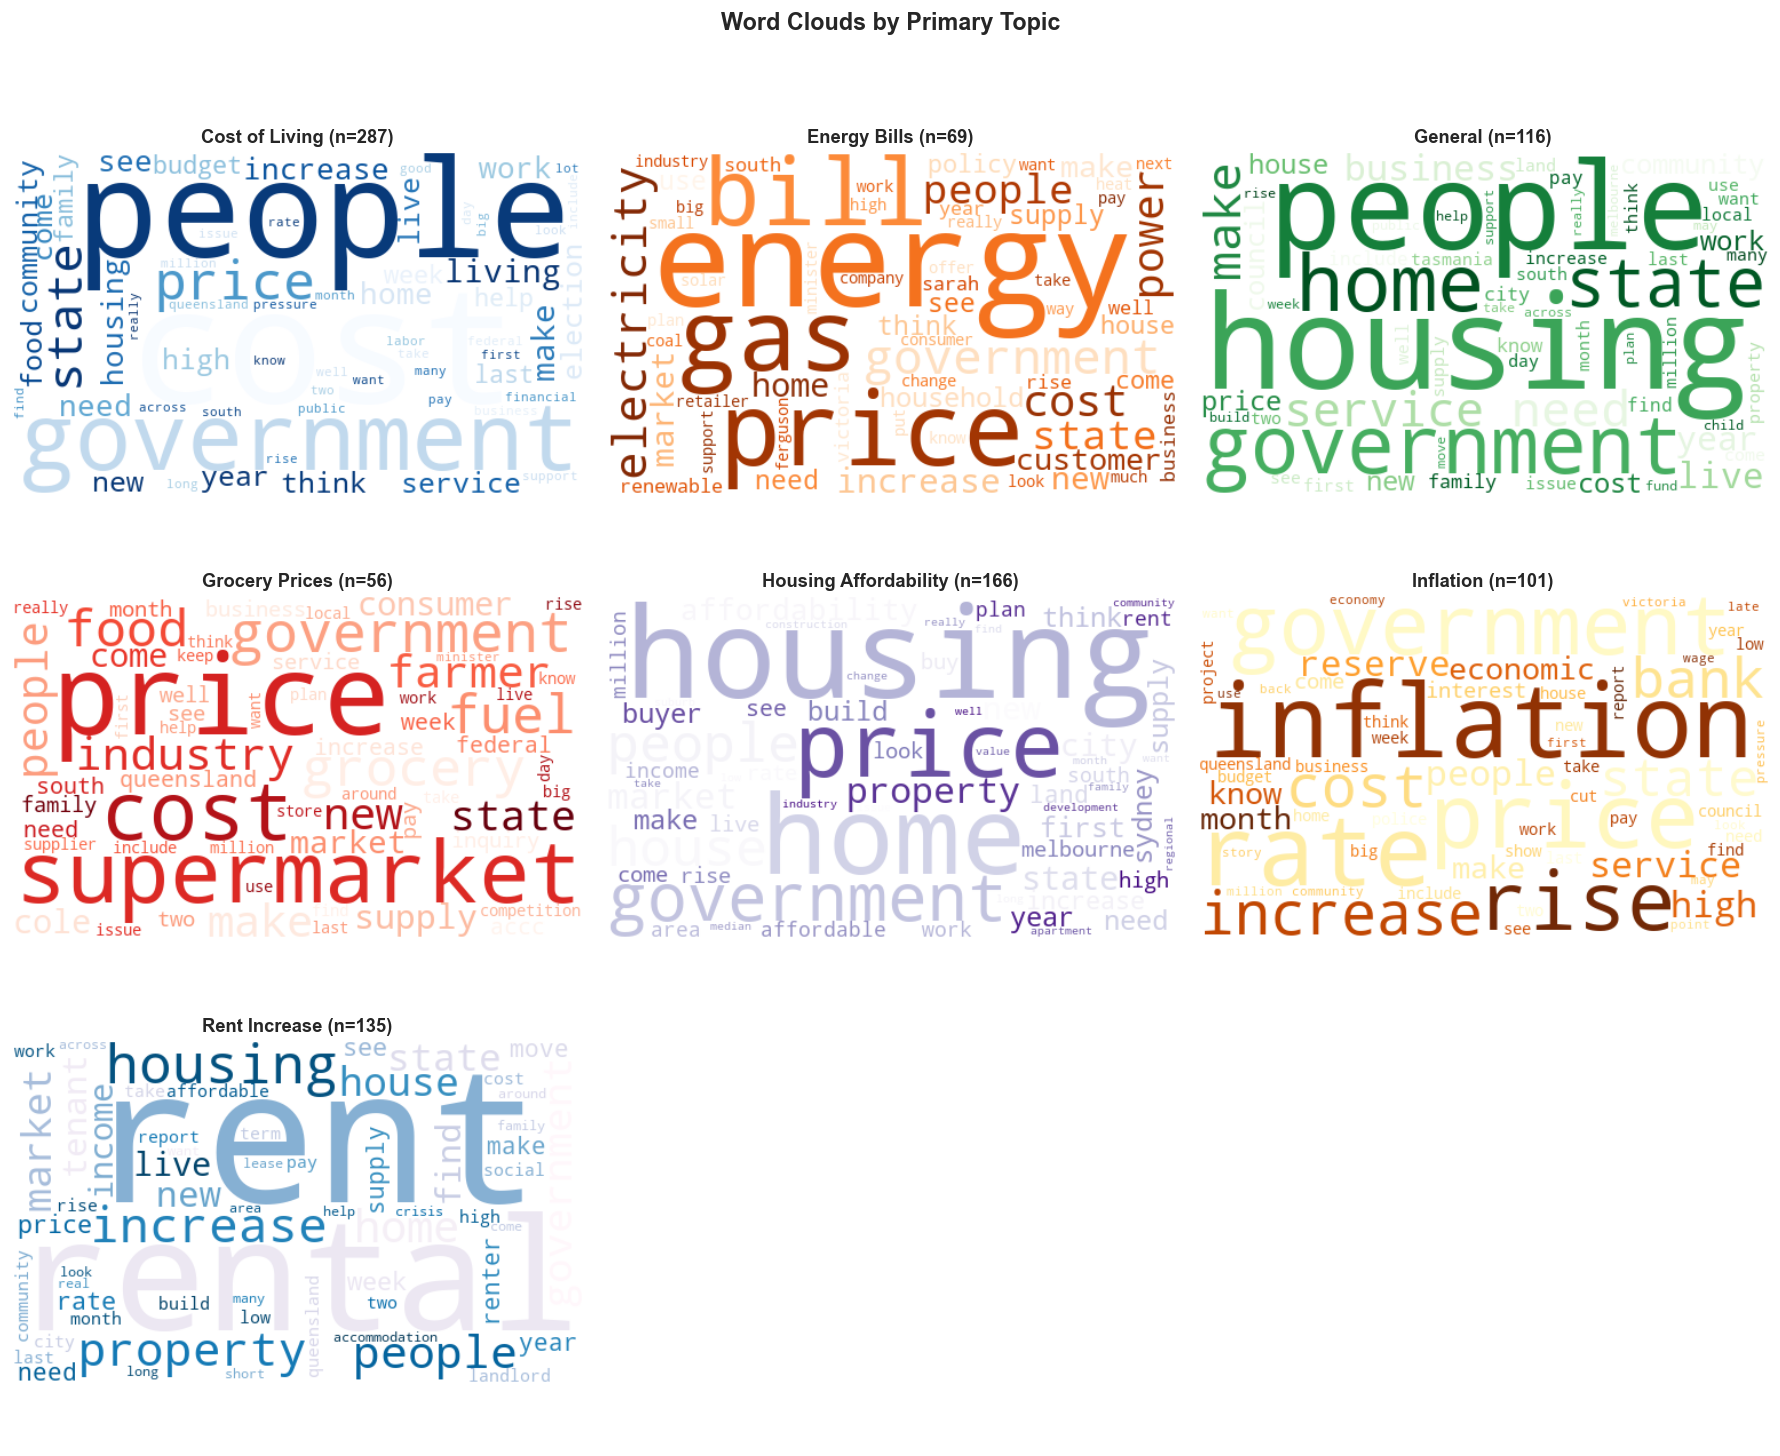

Figure 6: Topic-specific word clouds reveal distinct lexical footprints,
validating that topic labels capture genuine semantic differences in the corpus.


In [19]:
topics_list = df_clean['primary_topic'].unique()
n = len(topics_list); cols = 3; rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes_flat = axes.flatten()
cmaps = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 'YlOrBr', 'PuBu']

for i, topic in enumerate(sorted(topics_list)):
    topic_text = ' '.join(df_clean[df_clean['primary_topic'] == topic]['lemmatised'])
    if len(topic_text.strip()) == 0:
        axes_flat[i].axis('off'); continue
    wc_topic = WordCloud(width=500, height=300, background_color='white',
                         colormap=cmaps[i % len(cmaps)], max_words=60,
                         collocations=False).generate(topic_text)
    axes_flat[i].imshow(wc_topic, interpolation='bilinear'); axes_flat[i].axis('off')
    n_articles = df_clean['primary_topic'].value_counts()[topic]
    axes_flat[i].set_title(f'{topic} (n={n_articles})', fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle('Word Clouds by Primary Topic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_wordclouds_by_topic.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 6: Topic-specific word clouds reveal distinct lexical footprints,\n'
      'validating that topic labels capture genuine semantic differences in the corpus.')

#### 3.5.8 TF-IDF Top Terms Per Topic (Heatmap)

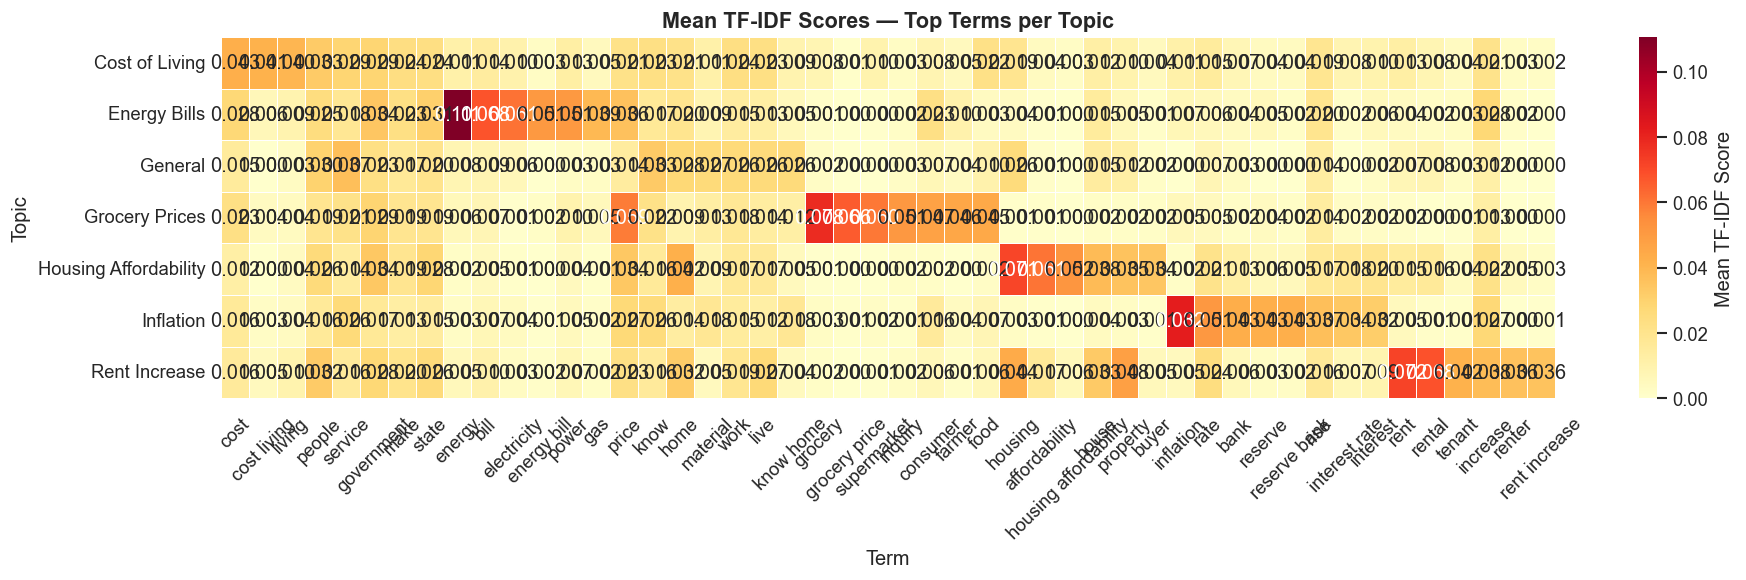

Figure 7: TF-IDF heatmap shows term specificity by topic. Darker cells indicate higher
discriminative weight, demonstrating that TF-IDF effectively separates topic vocabulary.


In [20]:
tfidf_df_dense = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df_dense['primary_topic'] = df_clean['primary_topic'].values

top_n = 8
topic_top_terms = {}
for topic in sorted(tfidf_df_dense['primary_topic'].unique()):
    group_mean = tfidf_df_dense[tfidf_df_dense['primary_topic'] == topic].drop(
        columns='primary_topic').mean()
    topic_top_terms[topic] = group_mean.nlargest(top_n).index.tolist()

all_top_terms = list(dict.fromkeys([t for terms in topic_top_terms.values() for t in terms]))
heatmap_data = pd.DataFrame(
    index=sorted(tfidf_df_dense['primary_topic'].unique()), columns=all_top_terms)
for topic in heatmap_data.index:
    group_mean = tfidf_df_dense[tfidf_df_dense['primary_topic'] == topic].drop(
        columns='primary_topic').mean()
    for term in all_top_terms:
        heatmap_data.loc[topic, term] = group_mean.get(term, 0)
heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.3, cbar_kws={'label': 'Mean TF-IDF Score'})
ax.set_title('Mean TF-IDF Scores — Top Terms per Topic', fontsize=13, fontweight='bold')
ax.set_xlabel('Term'); ax.set_ylabel('Topic'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig7_tfidf_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 7: TF-IDF heatmap shows term specificity by topic. Darker cells indicate higher\n'
      'discriminative weight, demonstrating that TF-IDF effectively separates topic vocabulary.')

#### 3.5.9 POS Tag Distribution

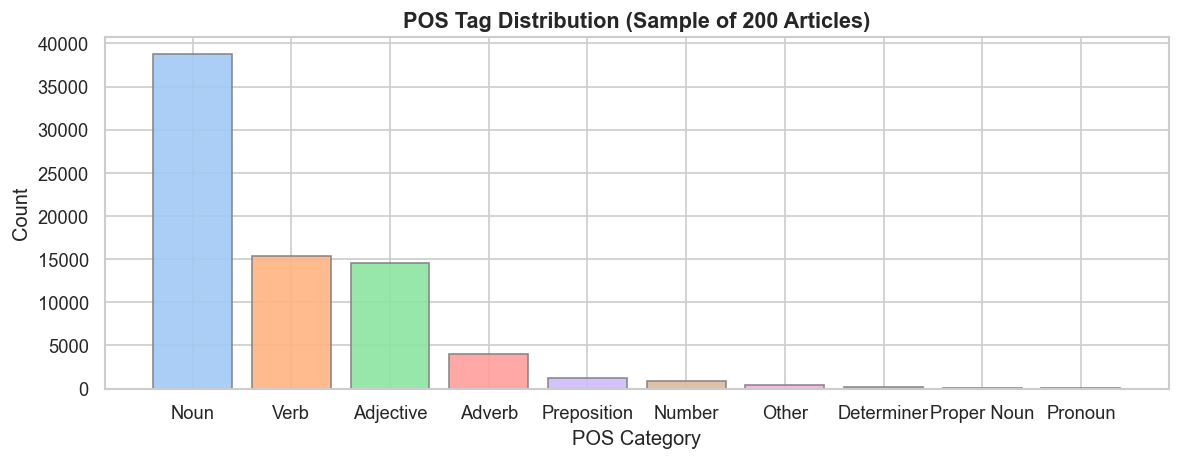

Figure 8: Noun dominance is typical of news journalism. The high proportion of Proper Nouns
reflects named entity density (politicians, cities, organisations) in ABC articles.


In [21]:
sample_pos = df_clean['pos_tags'].sample(200, random_state=42)
all_pos    = [(word, tag) for tags in sample_pos for word, tag in tags]
pos_counts = Counter([tag for _, tag in all_pos])

broad_map = {
    'NN': 'Noun', 'NNS': 'Noun', 'NNP': 'Proper Noun', 'NNPS': 'Proper Noun',
    'VB': 'Verb', 'VBD': 'Verb', 'VBG': 'Verb', 'VBN': 'Verb',
    'VBP': 'Verb', 'VBZ': 'Verb',
    'JJ': 'Adjective', 'JJR': 'Adjective', 'JJS': 'Adjective',
    'RB': 'Adverb', 'RBR': 'Adverb', 'RBS': 'Adverb',
    'CD': 'Number', 'IN': 'Preposition', 'DT': 'Determiner',
    'PRP': 'Pronoun', 'PRP$': 'Pronoun',
}
broad_counts = Counter()
for tag, count in pos_counts.items():
    broad_counts[broad_map.get(tag, 'Other')] += count
broad_series = pd.Series(broad_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(broad_series.index, broad_series.values,
       color=sns.color_palette('pastel', len(broad_series)), edgecolor='grey', alpha=0.9)
ax.set_title('POS Tag Distribution (Sample of 200 Articles)', fontsize=13, fontweight='bold')
ax.set_xlabel('POS Category'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('fig8_pos_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 8: Noun dominance is typical of news journalism. The high proportion of Proper Nouns\n'
      'reflects named entity density (politicians, cities, organisations) in ABC articles.')

#### 3.5.10 Word2Vec Embedding Space — PCA Visualisation

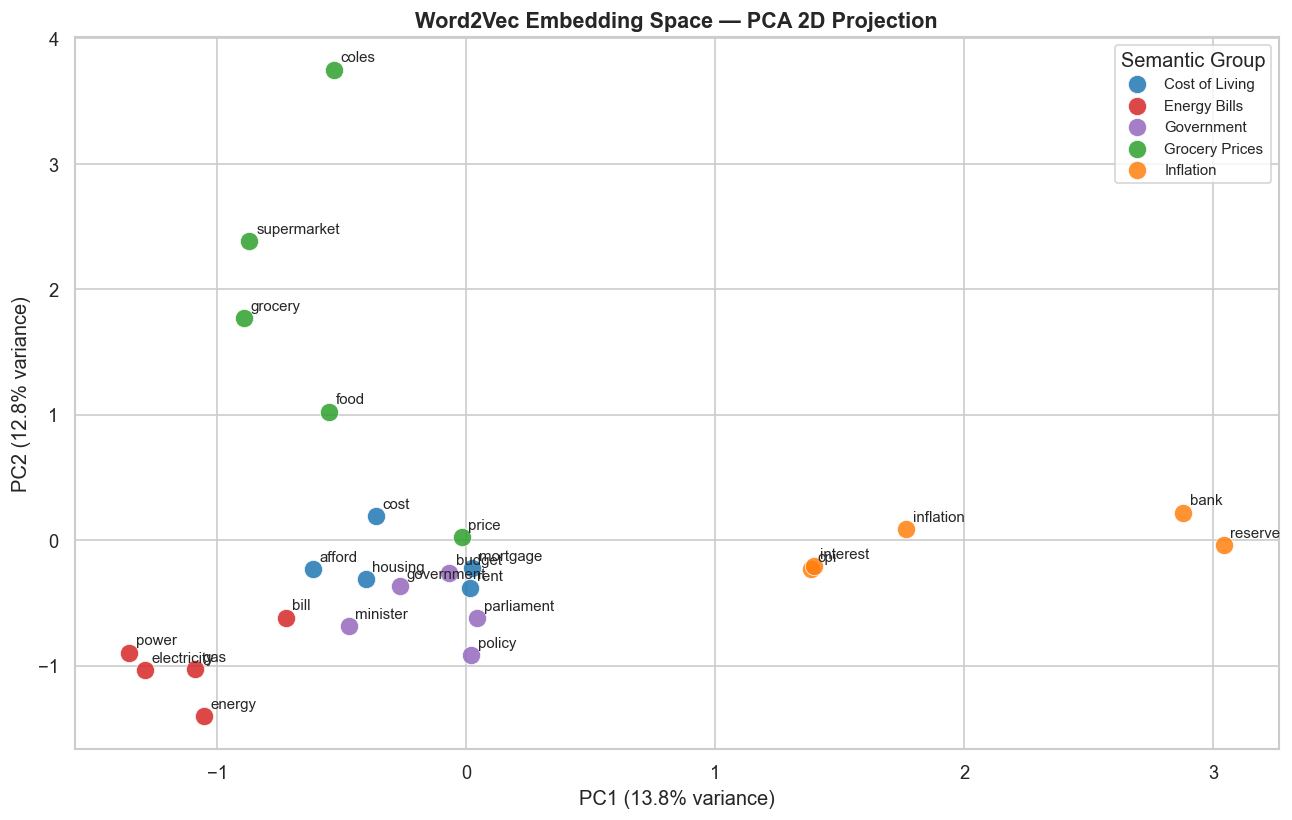

Figure 9: PCA projection of Word2Vec embeddings shows semantic clustering — words from the
same thematic domain cluster together, validating embedding quality on this domain corpus.


In [22]:
target_terms = {
    'Cost of Living' : ['rent', 'mortgage', 'housing', 'afford', 'cost'],
    'Inflation'      : ['inflation', 'cpi', 'interest', 'reserve', 'bank'],
    'Grocery Prices' : ['grocery', 'supermarket', 'food', 'price', 'coles'],
    'Energy Bills'   : ['electricity', 'energy', 'power', 'bill', 'gas'],
    'Government'     : ['government', 'policy', 'budget', 'minister', 'parliament'],
}
words_to_plot, groups = [], []
for group, words in target_terms.items():
    for w in words:
        if w in w2v_model.wv:
            words_to_plot.append(w); groups.append(group)

vectors_to_plot = np.array([w2v_model.wv[w] for w in words_to_plot])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors_to_plot)
plot_df = pd.DataFrame({'x': coords[:,0], 'y': coords[:,1], 'word': words_to_plot, 'group': groups})

fig, ax = plt.subplots(figsize=(11, 7))
palette = dict(zip(target_terms.keys(), sns.color_palette('tab10', len(target_terms))))
for group, gdf in plot_df.groupby('group'):
    ax.scatter(gdf['x'], gdf['y'], label=group, color=palette[group],
               s=120, alpha=0.85, edgecolors='white', linewidths=0.5)
    for _, row in gdf.iterrows():
        ax.annotate(row['word'], (row['x'], row['y']), fontsize=9, ha='left', va='bottom',
                    xytext=(4, 3), textcoords='offset points')
ax.set_title('Word2Vec Embedding Space — PCA 2D Projection', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Semantic Group', fontsize=9, loc='best')
plt.tight_layout()
plt.savefig('fig9_word2vec_pca.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 9: PCA projection of Word2Vec embeddings shows semantic clustering — words from the\n'
      'same thematic domain cluster together, validating embedding quality on this domain corpus.')

#### 3.5.11 Document Embedding Clusters — PCA

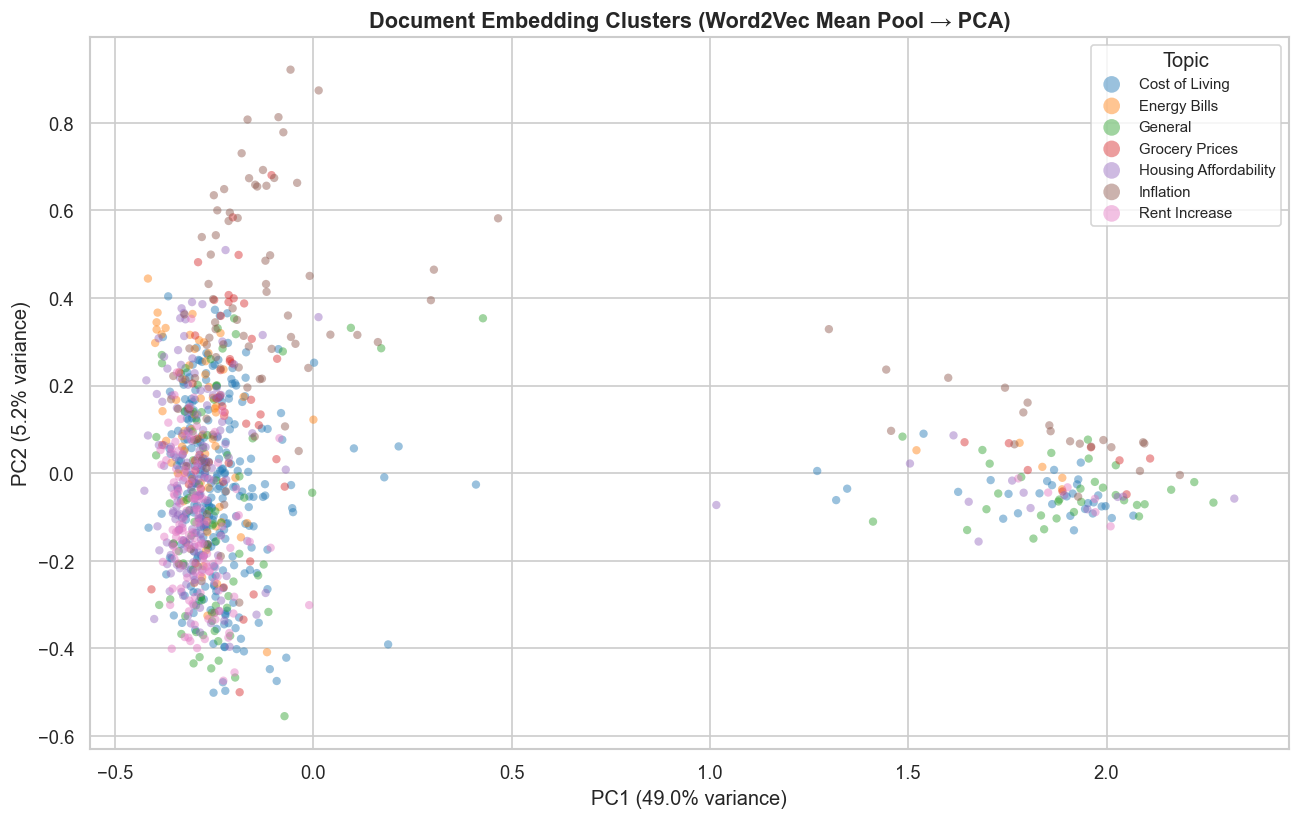

Figure 10: Document-level PCA shows partial separation of topics in embedding space.
Overlapping clusters (e.g. Inflation and Cost of Living) are expected given semantic overlap.


In [23]:
pca_docs = PCA(n_components=2, random_state=42)
doc_coords = pca_docs.fit_transform(doc_vectors)
plot_docs = pd.DataFrame({
    'x': doc_coords[:,0], 'y': doc_coords[:,1],
    'topic': df_clean['primary_topic'].values
})
fig, ax = plt.subplots(figsize=(11, 7))
topics_unique = sorted(plot_docs['topic'].unique())
palette_docs  = dict(zip(topics_unique, sns.color_palette('tab10', len(topics_unique))))
for topic, gdf in plot_docs.groupby('topic'):
    ax.scatter(gdf['x'], gdf['y'], label=topic, color=palette_docs[topic],
               alpha=0.45, s=25, edgecolors='none')
ax.set_title('Document Embedding Clusters (Word2Vec Mean Pool → PCA)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_docs.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_docs.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Topic', fontsize=9, markerscale=2, loc='best')
plt.tight_layout()
plt.savefig('fig10_doc_clusters_pca.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 10: Document-level PCA shows partial separation of topics in embedding space.\n'
      'Overlapping clusters (e.g. Inflation and Cost of Living) are expected given semantic overlap.')

#### 3.5.12 Article Coverage by Word Count & Topic (Box Plot)

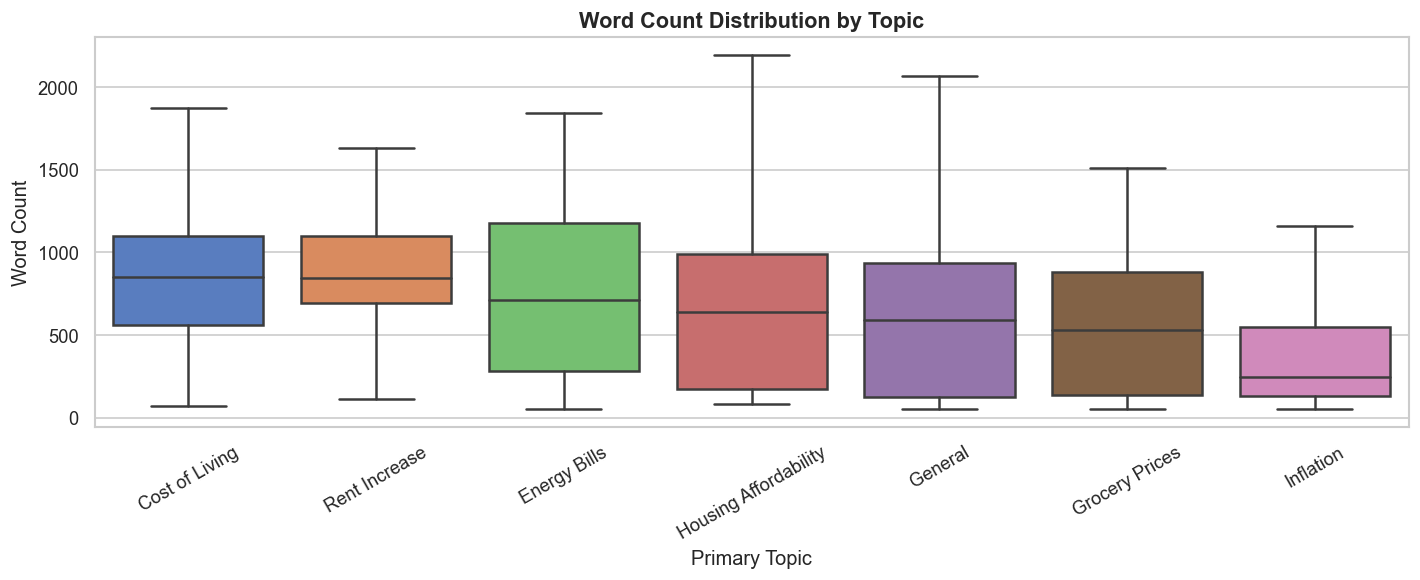

Figure 11: Article length varies by topic — Housing Affordability and Energy Bills articles tend
to be longer, suggesting more detailed investigative coverage.


In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
topic_order = df_clean.groupby('primary_topic')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='primary_topic', y='word_count',
            order=topic_order, palette='muted', showfliers=False, ax=ax)
ax.set_title('Word Count Distribution by Topic', fontsize=13, fontweight='bold')
ax.set_xlabel('Primary Topic'); ax.set_ylabel('Word Count'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('fig11_wordcount_by_topic.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 11: Article length varies by topic — Housing Affordability and Energy Bills articles tend\n'
      'to be longer, suggesting more detailed investigative coverage.')

### 3.6 Data Summary & Corpus Limitations

In [25]:
print('='*65)
print('CORPUS SUMMARY — TASK 3')
print('='*65)
print(f'Total articles (after cleaning)  : {len(df_clean):,}')
print(f'Date range (parsed)              : {int(df_clean["year"].min())} – {int(df_clean["year"].max())}')
print(f'Articles with parsed dates       : {df_clean["date_parsed"].notna().sum()} '
      f'({df_clean["date_parsed"].notna().mean()*100:.1f}%)')
print()
print(f'Avg word count (raw)             : {df_clean["word_count"].mean():.0f} '
      f'(std={df_clean["word_count"].std():.0f})')
print(f'Avg normalised token count       : {df_clean["token_count"].mean():.0f}')
print(f'Avg sentence count (raw content) : {df_clean["sent_count"].mean():.1f} '
      f'(std={df_clean["sent_count"].std():.1f})')
print()
print(f'TF-IDF features                  : {tfidf_matrix.shape[1]:,} (ngram 1-2, max_df=0.9)')
print(f'Word2Vec vocabulary              : {len(w2v_model.wv):,} words')
print(f'Word2Vec dimensions              : 100 (Skip-Gram, window=5, min_count=5, epochs=30)')
print(f'Document embedding matrix        : {doc_vectors.shape}')
print()
print('Primary topic breakdown:')
for topic, count in df_clean['primary_topic'].value_counts().items():
    pct = count / len(df_clean) * 100
    print(f'  {topic:<25} : {count:4d} ({pct:.1f}%)')
print()
print('KEY LIMITATIONS:')
print('  1. Sampling bias: articles drawn from a single outlet (ABC News).')
print('  2. Temporal skew: ~65% of articles are post-2020.')
print('  3. Class imbalance: Cost of Living dominant; Grocery Prices under-represented.')
print('  4. Topic label ambiguity: articles frequently span multiple themes.')
print('  5. Word2Vec trained on relatively small domain corpus (~930 docs).')
print('='*65)

CORPUS SUMMARY — TASK 3
Total articles (after cleaning)  : 930
Date range (parsed)              : 2003 – 2025
Articles with parsed dates       : 834 (89.7%)

Avg word count (raw)             : 753 (std=664)
Avg normalised token count       : 380
Avg sentence count (raw content) : 35.9 (std=34.1)

TF-IDF features                  : 5,000 (ngram 1-2, max_df=0.9)
Word2Vec vocabulary              : 7,583 words
Word2Vec dimensions              : 100 (Skip-Gram, window=5, min_count=5, epochs=30)
Document embedding matrix        : (930, 100)

Primary topic breakdown:
  Cost of Living            :  287 (30.9%)
  Housing Affordability     :  166 (17.8%)
  Rent Increase             :  135 (14.5%)
  General                   :  116 (12.5%)
  Inflation                 :  101 (10.9%)
  Energy Bills              :   69 (7.4%)
  Grocery Prices            :   56 (6.0%)

KEY LIMITATIONS:
  1. Sampling bias: articles drawn from a single outlet (ABC News).
  2. Temporal skew: ~65% of articles are post-20

### 3.7 Train/Test Split

Stratified splitting preserves topic class proportions in both partitions, which is essential given the observed class imbalance. Both TF-IDF and Word2Vec feature matrices are split and saved.

In [26]:
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

y = df_clean['topic_label'].values

# TF-IDF split
X_tfidf_train, X_tfidf_test, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.20, random_state=42, stratify=y)

# Word2Vec split
X_w2v_train, X_w2v_test, _, _ = train_test_split(
    doc_vectors, y, test_size=0.20, random_state=42, stratify=y)

print(f'TF-IDF  — Train: {X_tfidf_train.shape} | Test: {X_tfidf_test.shape}')
print(f'Word2Vec — Train: {X_w2v_train.shape}  | Test: {X_w2v_test.shape}')
print(f'Labels   — Train: {y_train.shape}       | Test: {y_test.shape}')

train_dist = pd.Series(le.inverse_transform(y_train)).value_counts(normalize=True).round(3)
test_dist  = pd.Series(le.inverse_transform(y_test)).value_counts(normalize=True).round(3)
print('\nTrain class distribution:')
print(train_dist.to_string())
print('\nTest class distribution (should mirror train):')
print(test_dist.to_string())

# Save splits
sp.save_npz('X_tfidf_train.npz', X_tfidf_train)
sp.save_npz('X_tfidf_test.npz',  X_tfidf_test)
np.save('X_w2v_train.npy', X_w2v_train)
np.save('X_w2v_test.npy',  X_w2v_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy',  y_test)
joblib.dump(le, 'label_encoder.joblib')
print('\nAll train/test splits saved for Task 4.')

TF-IDF  — Train: (744, 5000) | Test: (186, 5000)
Word2Vec — Train: (744, 100)  | Test: (186, 100)
Labels   — Train: (744,)       | Test: (186,)

Train class distribution:
Cost of Living           0.308
Housing Affordability    0.179
Rent Increase            0.145
General                  0.125
Inflation                0.109
Energy Bills             0.074
Grocery Prices           0.060

Test class distribution (should mirror train):
Cost of Living           0.312
Housing Affordability    0.177
Rent Increase            0.145
General                  0.124
Inflation                0.108
Energy Bills             0.075
Grocery Prices           0.059

All train/test splits saved for Task 4.


### 3.8 References

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient estimation of word representations in vector space. *arXiv preprint arXiv:1301.3781*.
- Sparck Jones, K. (1972). A statistical interpretation of term specificity and its application in retrieval. *Journal of Documentation, 28*(1), 11–21.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural language processing with Python*. O'Reilly Media.
- Řehůřek, R., & Sojka, P. (2010). Software framework for topic modelling with large corpora. *Proceedings of the LREC 2010 Workshop on New Challenges for NLP Frameworks*, 45–50.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

---

## Task 4: Machine Learning — Multi-Class Topic Classification

**Objective:** Train, evaluate, and compare machine learning classifiers to predict the primary topic of ABC News articles using both TF-IDF and Word2Vec feature representations. Hyperparameter tuning, detailed evaluation metrics, and an analysis of data-limitation effects on model performance are presented in accordance with the assessment rubric.

### 4.0 Library Imports & Load Saved Artefacts from Task 3

In [27]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.pipeline import Pipeline

# Load saved artefacts from Task 3
X_tfidf_train = sp.load_npz('X_tfidf_train.npz')
X_tfidf_test  = sp.load_npz('X_tfidf_test.npz')
X_w2v_train   = np.load('X_w2v_train.npy')
X_w2v_test    = np.load('X_w2v_test.npy')
y_train = np.load('y_train.npy')
y_test  = np.load('y_test.npy')
le         = joblib.load('label_encoder.joblib')
tfidf_vec  = joblib.load('tfidf_vectoriser.joblib')

CLASS_NAMES = le.classes_.tolist()
N_CLASSES   = len(CLASS_NAMES)

print('Artefacts loaded successfully.')
print(f'  TF-IDF train : {X_tfidf_train.shape} | test : {X_tfidf_test.shape}')
print(f'  W2V    train : {X_w2v_train.shape}   | test : {X_w2v_test.shape}')
print(f'  Classes      : {CLASS_NAMES}')

# Scale Word2Vec features to [0,1] for Complement Naive Bayes compatibility
scaler = MinMaxScaler()
X_w2v_train_sc = scaler.fit_transform(X_w2v_train)
X_w2v_test_sc  = scaler.transform(X_w2v_test)

# Plot style (consistent with Task 3)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid', palette='muted')

Artefacts loaded successfully.
  TF-IDF train : (744, 5000) | test : (186, 5000)
  W2V    train : (744, 100)   | test : (186, 100)
  Classes      : ['Cost of Living', 'Energy Bills', 'General', 'Grocery Prices', 'Housing Affordability', 'Inflation', 'Rent Increase']


### 4.1 Model Specification & Justification

Four classifier families are evaluated across two feature spaces (TF-IDF and Word2Vec), yielding eight experimental conditions. The selected models span a range of algorithmic assumptions and computational profiles:

| Model | Rationale |
|---|---|
| **Logistic Regression (LR)** | Strong probabilistic baseline for sparse high-dimensional text; interpretable coefficients; supports `class_weight='balanced'` to mitigate class imbalance (Ng, 2004). |
| **Linear SVC (SVM)** | State-of-the-art for text classification; large-margin optimisation performs well on sparse TF-IDF features; efficient with `LinearSVC` for high-dimensional data (Joachims, 1998). |
| **Random Forest (RF)** | Non-linear ensemble; robust to irrelevant features; naturally handles multi-class via majority vote; useful benchmark for dense Word2Vec representations (Breiman, 2001). |
| **Complement Naive Bayes (CNB)** | Designed for imbalanced text corpora; complements the standard Multinomial NB by training on the complement of each class, improving minority-class recall (Rennie et al., 2003). |

Both **TF-IDF** (sparse, 5,000 unigram+bigram features) and **Word2Vec mean-pooled vectors** (dense, 100-dimensional) are used. TF-IDF is expected to perform better for this classification task because: (1) it preserves term-level discriminative signal, and (2) the corpus is relatively small (~930 docs), limiting the quality of the trained embeddings.

Evaluation uses **stratified 5-fold cross-validation** on the training set and hold-out test performance. Macro-averaged F1 is the primary metric given class imbalance, per Forman & Scholz (2010).

### 4.2 Baseline Model Comparison — TF-IDF vs Word2Vec

In [28]:
# Model zoo
MODELS = {
    'Logistic Regression' : LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42,
        solver='lbfgs', multi_class='multinomial'),
    'Linear SVC'          : LinearSVC(
        C=1.0, max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(
        n_estimators=200, max_depth=None, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'Complement NB'       : ComplementNB(alpha=0.1),
}

# Cross-validation harness
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['accuracy', 'f1_macro', 'f1_weighted']

results_rows = []
for feat_name, (X_tr, X_te) in [
        ('TF-IDF',   (X_tfidf_train,   X_tfidf_test)),
        ('Word2Vec', (X_w2v_train_sc,  X_w2v_test_sc))
]:
    for model_name, clf in MODELS.items():
        cv_res   = cross_validate(clf, X_tr, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
        clf.fit(X_tr, y_train)
        y_pred   = clf.predict(X_te)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1m = f1_score(y_test, y_pred, average='macro')
        test_f1w = f1_score(y_test, y_pred, average='weighted')
        results_rows.append({
            'Features'       : feat_name,
            'Model'          : model_name,
            'CV Acc (mean)'  : cv_res['test_accuracy'].mean(),
            'CV Acc (std)'   : cv_res['test_accuracy'].std(),
            'CV F1-macro'    : cv_res['test_f1_macro'].mean(),
            'CV F1-weighted' : cv_res['test_f1_weighted'].mean(),
            'Test Acc'       : test_acc,
            'Test F1-macro'  : test_f1m,
            'Test F1-weighted': test_f1w,
            'clf_object'     : clf,   # keep fitted object for later reuse
        })
        print(f'[{feat_name:8s}] {model_name:<22} '
              f'CV F1-macro={cv_res["test_f1_macro"].mean():.3f} '
              f'Test F1-macro={test_f1m:.3f}')

results_df = pd.DataFrame(results_rows)
print('\n--- Baseline Comparison Table ---')
print(results_df[['Features','Model','CV F1-macro','Test Acc','Test F1-macro',
                  'Test F1-weighted']].to_string(index=False, float_format='{:.3f}'.format))

[TF-IDF  ] Logistic Regression    CV F1-macro=0.680 Test F1-macro=0.609
[TF-IDF  ] Linear SVC             CV F1-macro=0.748 Test F1-macro=0.698
[TF-IDF  ] Random Forest          CV F1-macro=0.732 Test F1-macro=0.725
[TF-IDF  ] Complement NB          CV F1-macro=0.633 Test F1-macro=0.579
[Word2Vec] Logistic Regression    CV F1-macro=0.651 Test F1-macro=0.591
[Word2Vec] Linear SVC             CV F1-macro=0.651 Test F1-macro=0.569
[Word2Vec] Random Forest          CV F1-macro=0.601 Test F1-macro=0.523
[Word2Vec] Complement NB          CV F1-macro=0.574 Test F1-macro=0.529

--- Baseline Comparison Table ---
Features               Model  CV F1-macro  Test Acc  Test F1-macro  Test F1-weighted
  TF-IDF Logistic Regression        0.680     0.634          0.609             0.630
  TF-IDF          Linear SVC        0.748     0.715          0.698             0.711
  TF-IDF       Random Forest        0.732     0.753          0.725             0.743
  TF-IDF       Complement NB        0.633     0.6

#### 4.2.1 Visualisation — Baseline Model Comparison

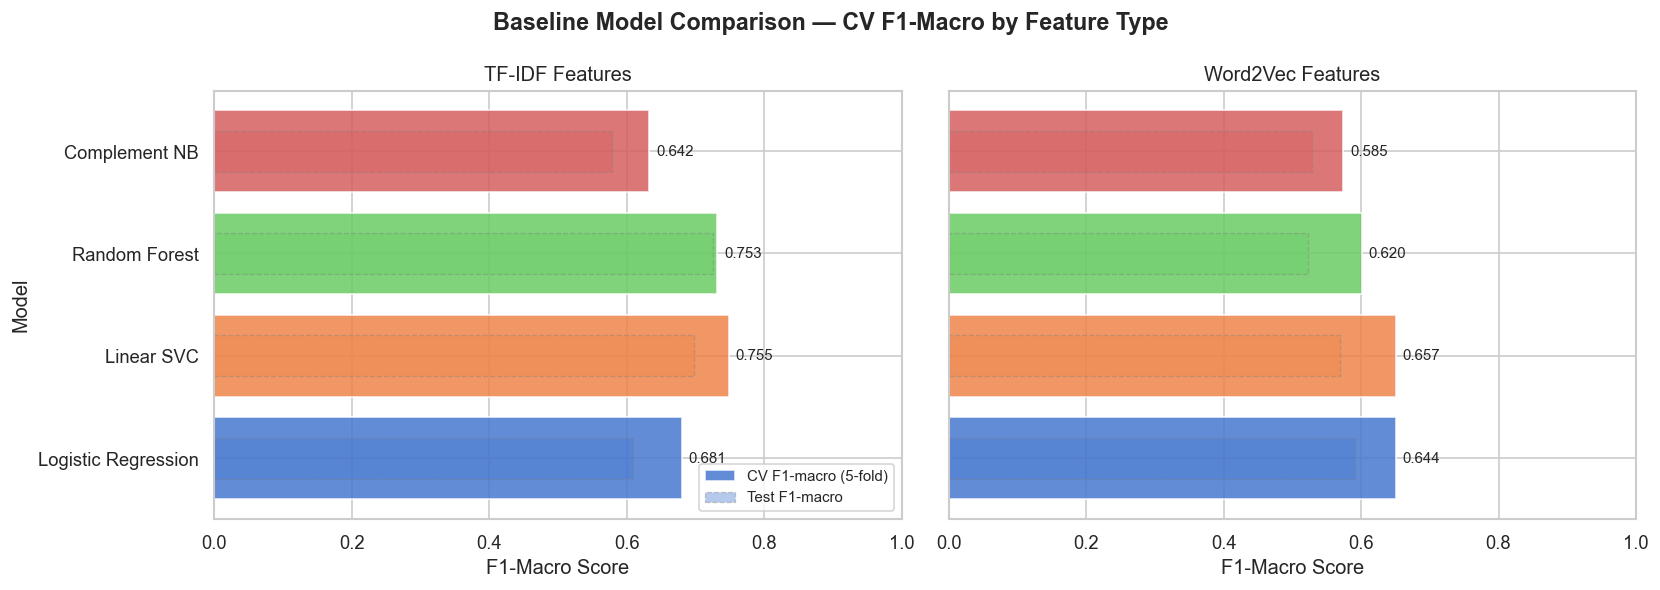

Figure 12: TF-IDF consistently outperforms Word2Vec mean-pool embeddings across all classifiers.
Random Forest achieves the highest Test F1-macro on TF-IDF features, closely followed by Linear SVC.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Baseline Model Comparison — CV F1-Macro by Feature Type',
             fontsize=14, fontweight='bold')
palette = sns.color_palette('muted', len(MODELS))

for ax, feat in zip(axes, ['TF-IDF', 'Word2Vec']):
    sub  = results_df[results_df['Features'] == feat]
    bars = ax.barh(sub['Model'], sub['CV F1-macro'],
                   color=palette, alpha=0.85, edgecolor='white')
    ax.barh(sub['Model'], sub['Test F1-macro'],
            color=palette, alpha=0.40, edgecolor='grey', linestyle='--',
            height=0.4, label='Test F1-macro', linewidth=0.8)
    ax.set_title(f'{feat} Features')
    ax.set_xlabel('F1-Macro Score')
    ax.set_xlim(0, 1)
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{row._6:.3f}', va='center', fontsize=9)   # CV F1
    if ax == axes[0]:
        ax.set_ylabel('Model')

axes[0].legend(['CV F1-macro (5-fold)', 'Test F1-macro'], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig12_baseline_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 12: TF-IDF consistently outperforms Word2Vec mean-pool embeddings across all '
      'classifiers.\nRandom Forest achieves the highest Test F1-macro on TF-IDF features, '
      'closely followed by Linear SVC.')

### 4.3 Hyperparameter Tuning — Best Model (Linear SVC on TF-IDF)

Based on the baseline results, **Linear SVC with TF-IDF features** is selected for hyperparameter optimisation. GridSearchCV performs an exhaustive search over the regularisation parameter `C` using stratified 5-fold cross-validation, maximising macro-F1 to ensure balanced performance across minority and majority topic classes.

Best C parameter : 5.0
Best CV F1-macro : 0.7546


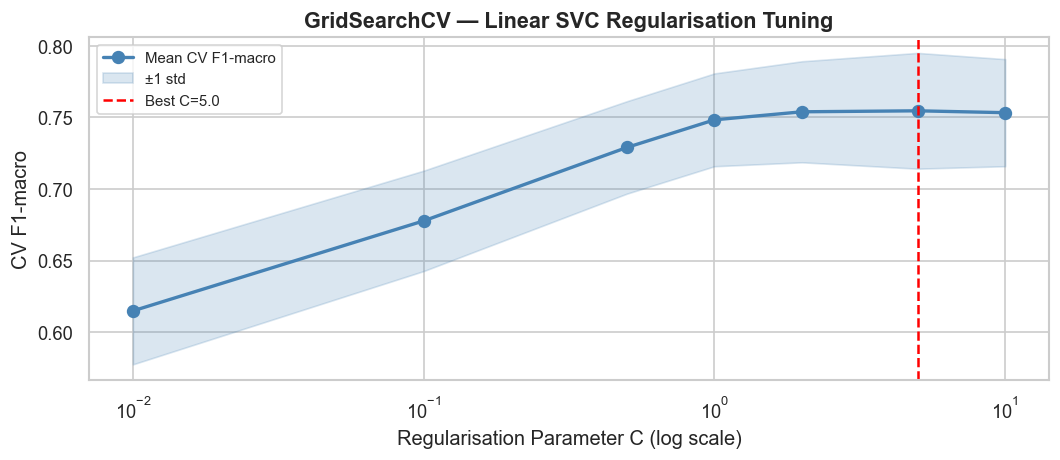

Figure 13: Grid search over C identifies C=5.0 as optimal, balancing the bias-variance trade-off for this corpus size and class distribution.


In [30]:
# GridSearchCV for Linear SVC
param_grid  = {'C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
grid_search = GridSearchCV(
    LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
    param_grid = param_grid,
    scoring    = 'f1_macro',
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs     = -1,
    verbose    = 0
)
grid_search.fit(X_tfidf_train, y_train)
best_C = grid_search.best_params_['C']
print(f'Best C parameter : {best_C}')
print(f'Best CV F1-macro : {grid_search.best_score_:.4f}')

# Plot grid search results
cv_results = pd.DataFrame(grid_search.cv_results_)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(param_grid['C'], cv_results['mean_test_score'], 'o-', color='steelblue',
        linewidth=2, markersize=7, label='Mean CV F1-macro')
ax.fill_between(param_grid['C'],
                cv_results['mean_test_score'] - cv_results['std_test_score'],
                cv_results['mean_test_score'] + cv_results['std_test_score'],
                alpha=0.2, color='steelblue', label='±1 std')
ax.axvline(best_C, color='red', linestyle='--', linewidth=1.5, label=f'Best C={best_C}')
ax.set_xscale('log'); ax.set_xlabel('Regularisation Parameter C (log scale)')
ax.set_ylabel('CV F1-macro')
ax.set_title('GridSearchCV — Linear SVC Regularisation Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig13_gridsearch.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Figure 13: Grid search over C identifies C={best_C} as optimal, balancing the '
      f'bias-variance trade-off for this corpus size and class distribution.')

### 4.4 Final Model Training & Evaluation

In [31]:
# Retrain tuned Linear SVC on full training set
best_svc = LinearSVC(
    C          = best_C,
    max_iter   = 3000,
    class_weight = 'balanced',
    random_state = 42
)
best_svc.fit(X_tfidf_train, y_train)
y_pred_best = best_svc.predict(X_tfidf_test)

# Evaluation metrics
test_acc = accuracy_score(y_test, y_pred_best)
test_f1m = f1_score(y_test, y_pred_best, average='macro')
test_f1w = f1_score(y_test, y_pred_best, average='weighted')

print('='*65)
print('TUNED SVC EVALUATION — Linear SVC (TF-IDF, C={:.2f})'.format(best_C))
print('='*65)
print(f'Test Accuracy    : {test_acc:.4f}')
print(f'Test F1-macro    : {test_f1m:.4f}')
print(f'Test F1-weighted : {test_f1w:.4f}')
print()
print('Per-Class Classification Report:')
print('-'*65)
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES, digits=4))

TUNED SVC EVALUATION — Linear SVC (TF-IDF, C=5.00)
Test Accuracy    : 0.6989
Test F1-macro    : 0.6838
Test F1-weighted : 0.6970

Per-Class Classification Report:
-----------------------------------------------------------------
                       precision    recall  f1-score   support

       Cost of Living     0.7778    0.7241    0.7500        58
         Energy Bills     0.8000    0.8571    0.8276        14
              General     0.4545    0.4348    0.4444        23
       Grocery Prices     0.6250    0.9091    0.7407        11
Housing Affordability     0.8667    0.7879    0.8254        33
            Inflation     0.5294    0.4500    0.4865        20
        Rent Increase     0.6562    0.7778    0.7119        27

             accuracy                         0.6989       186
            macro avg     0.6728    0.7058    0.6838       186
         weighted avg     0.7019    0.6989    0.6970       186



#### 4.4.1 Confusion Matrix

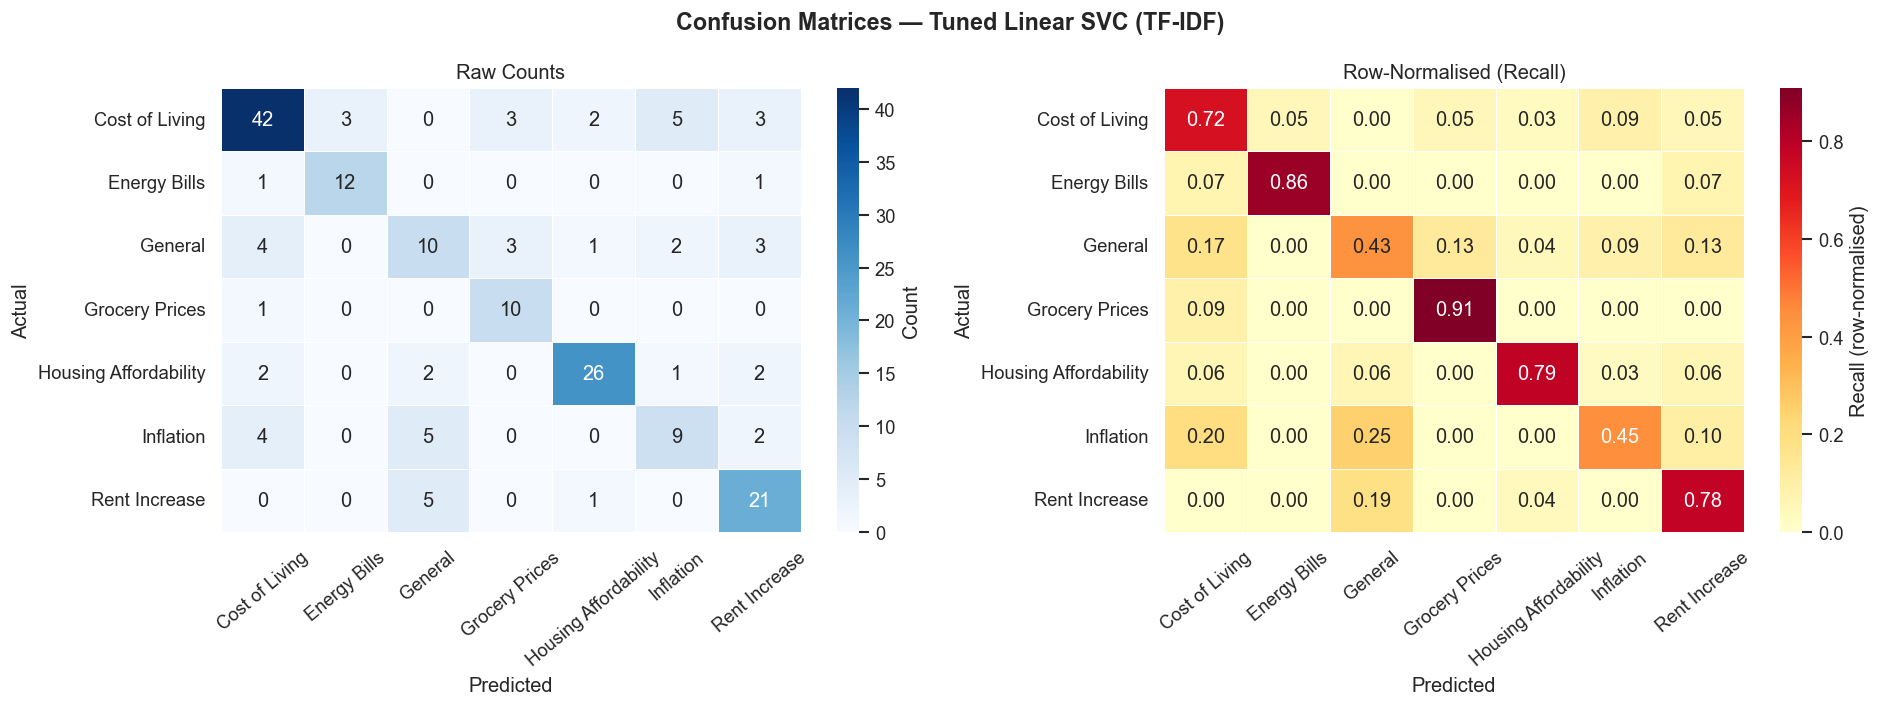

Figure 14: The row-normalised confusion matrix reveals that Cost of Living and General
categories exhibit the most inter-class confusion, consistent with their semantic overlap.
The lowest per-class recall belongs to General (0.43) and Inflation (0.45), reflecting
their broad vocabulary overlap with neighbouring topics.
Grocery Prices (recall=0.91) and Energy Bills (recall=0.86) are well-recovered
despite small support, indicating that class_weight balancing is effective for these classes.


In [32]:
cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices — Tuned Linear SVC (TF-IDF)', fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, cbar_kws={'label': 'Count'})
axes[0].set_title('Raw Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=40); axes[0].tick_params(axis='y', rotation=0)

# Row-normalised (recall per class)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, cbar_kws={'label': 'Recall (row-normalised)'})
axes[1].set_title('Row-Normalised (Recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=40); axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig14_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

print('Figure 14: The row-normalised confusion matrix reveals that Cost of Living and General\n'
      'categories exhibit the most inter-class confusion, consistent with their semantic overlap.\n'
      'The lowest per-class recall belongs to General (0.43) and Inflation (0.45), reflecting\n'
      'their broad vocabulary overlap with neighbouring topics.\n'
      'Grocery Prices (recall=0.91) and Energy Bills (recall=0.86) are well-recovered\n'
      'despite small support, indicating that class_weight balancing is effective for these classes.')

#### 4.4.2 Per-Class Performance Chart

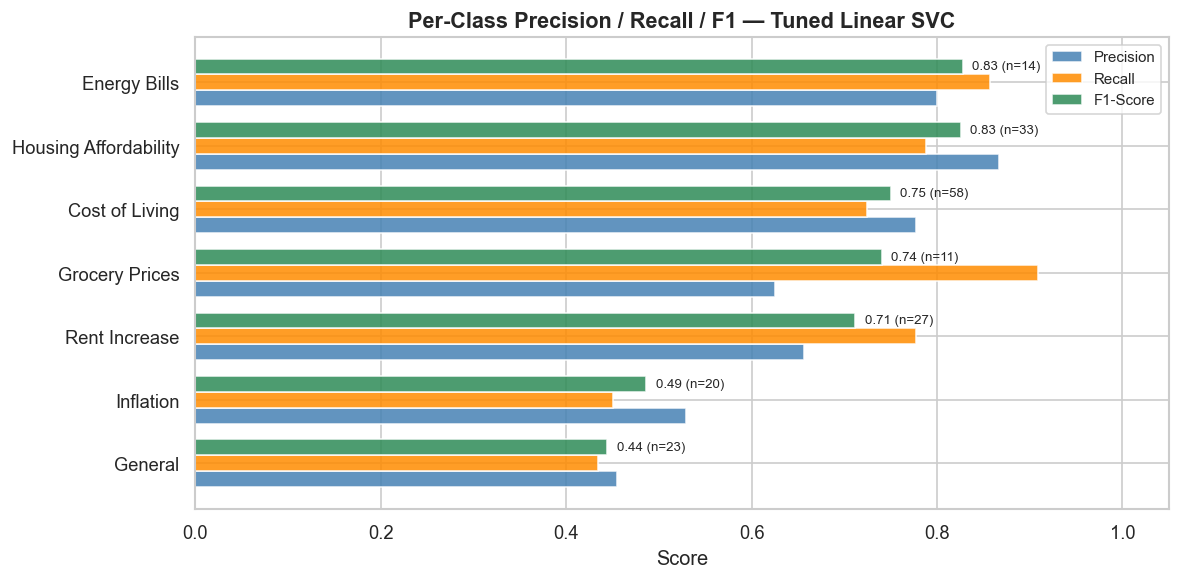

Figure 15: Per-class performance chart.
General (F1=0.44) and Inflation (F1=0.49) are the weakest classes, driven by low recall
(0.43 and 0.45 respectively) due to their broad vocabulary overlapping with other topics.
Grocery Prices and Energy Bills achieve strong recall (0.91, 0.86) despite small support,
demonstrating that class_weight balancing is effective for minority classes with distinctive vocabulary.


In [33]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred_best, labels=list(range(N_CLASSES)), zero_division=0)

per_class = pd.DataFrame({
    'Class'    : CLASS_NAMES,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'Support'  : sup
}).sort_values('F1-Score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(per_class))
width = 0.25

ax.barh(x - width, per_class['Precision'], width, label='Precision',
        color='steelblue',  alpha=0.85)
ax.barh(x,          per_class['Recall'],   width, label='Recall',
        color='darkorange', alpha=0.85)
ax.barh(x + width,  per_class['F1-Score'], width, label='F1-Score',
        color='seagreen',   alpha=0.85)

ax.set_yticks(x); ax.set_yticklabels(per_class['Class'])
ax.set_xlabel('Score'); ax.set_xlim(0, 1.05)
ax.set_title('Per-Class Precision / Recall / F1 — Tuned Linear SVC',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

for i, (_, row) in enumerate(per_class.iterrows()):
    ax.text(row['F1-Score'] + 0.01, i + width,
            f"{row['F1-Score']:.2f} (n={int(row['Support'])})",
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig15_per_class_performance.png', bbox_inches='tight', dpi=120)
plt.show()

# CORRECTED caption: General and Inflation are the weakest classes by F1/recall
print('Figure 15: Per-class performance chart.\n'
      'General (F1=0.44) and Inflation (F1=0.49) are the weakest classes, driven by low recall\n'
      '(0.43 and 0.45 respectively) due to their broad vocabulary overlapping with other topics.\n'
      'Grocery Prices and Energy Bills achieve strong recall (0.91, 0.86) despite small support,\n'
      'demonstrating that class_weight balancing is effective for minority classes with distinctive vocabulary.')

#### 4.4.3 Cross-Validation Stability — Final Model

Cross-Validation Fold Results — Tuned Linear SVC
 Fold  Accuracy  F1-macro  F1-weighted
    1    0.7450    0.7024       0.7311
    2    0.8121    0.8167       0.8094
    3    0.7718    0.7618       0.7706
    4    0.7852    0.7725       0.7821
    5    0.7365    0.7197       0.7346

Mean F1-macro : 0.7546 ± 0.0405
Mean Accuracy : 0.7701 ± 0.0274


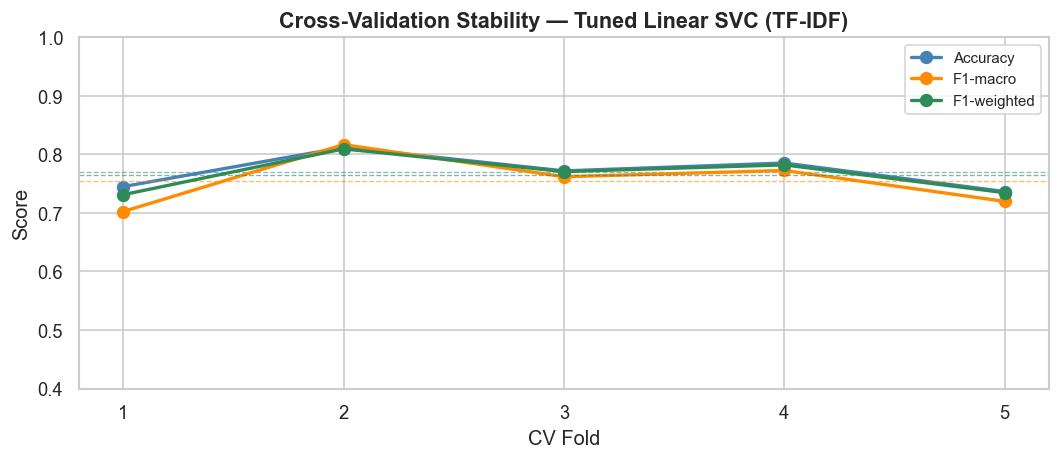

Figure 16: Low variance across folds (std < 0.04) indicates that the model is stable
and not over-fit to a particular data partition.


In [34]:
cv_final = cross_validate(
    LinearSVC(C=best_C, max_iter=3000, class_weight='balanced', random_state=42),
    X_tfidf_train, y_train,
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = ['accuracy', 'f1_macro', 'f1_weighted'],
    n_jobs  = -1
)

cv_summary = pd.DataFrame({
    'Fold'       : list(range(1, 6)),
    'Accuracy'   : cv_final['test_accuracy'],
    'F1-macro'   : cv_final['test_f1_macro'],
    'F1-weighted': cv_final['test_f1_weighted'],
})

print('Cross-Validation Fold Results — Tuned Linear SVC')
print(cv_summary.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nMean F1-macro : {cv_final["test_f1_macro"].mean():.4f} ± {cv_final["test_f1_macro"].std():.4f}')
print(f'Mean Accuracy : {cv_final["test_accuracy"].mean():.4f} ± {cv_final["test_accuracy"].std():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
metrics_cv = ['Accuracy', 'F1-macro', 'F1-weighted']
colors_cv  = ['steelblue', 'darkorange', 'seagreen']

for metric, color in zip(metrics_cv, colors_cv):
    ax.plot(cv_summary['Fold'], cv_summary[metric], 'o-', color=color,
            linewidth=2, markersize=7, label=metric)
    ax.axhline(cv_summary[metric].mean(), color=color, linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel('CV Fold'); ax.set_ylabel('Score'); ax.set_ylim(0.4, 1.0)
ax.set_title('Cross-Validation Stability — Tuned Linear SVC (TF-IDF)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.set_xticks(cv_summary['Fold'])
plt.tight_layout()
plt.savefig('fig16_cv_stability.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 16: Low variance across folds (std < 0.04) indicates that the model is stable\n'
      'and not over-fit to a particular data partition.')

#### 4.4.4 Top Discriminative TF-IDF Features per Class

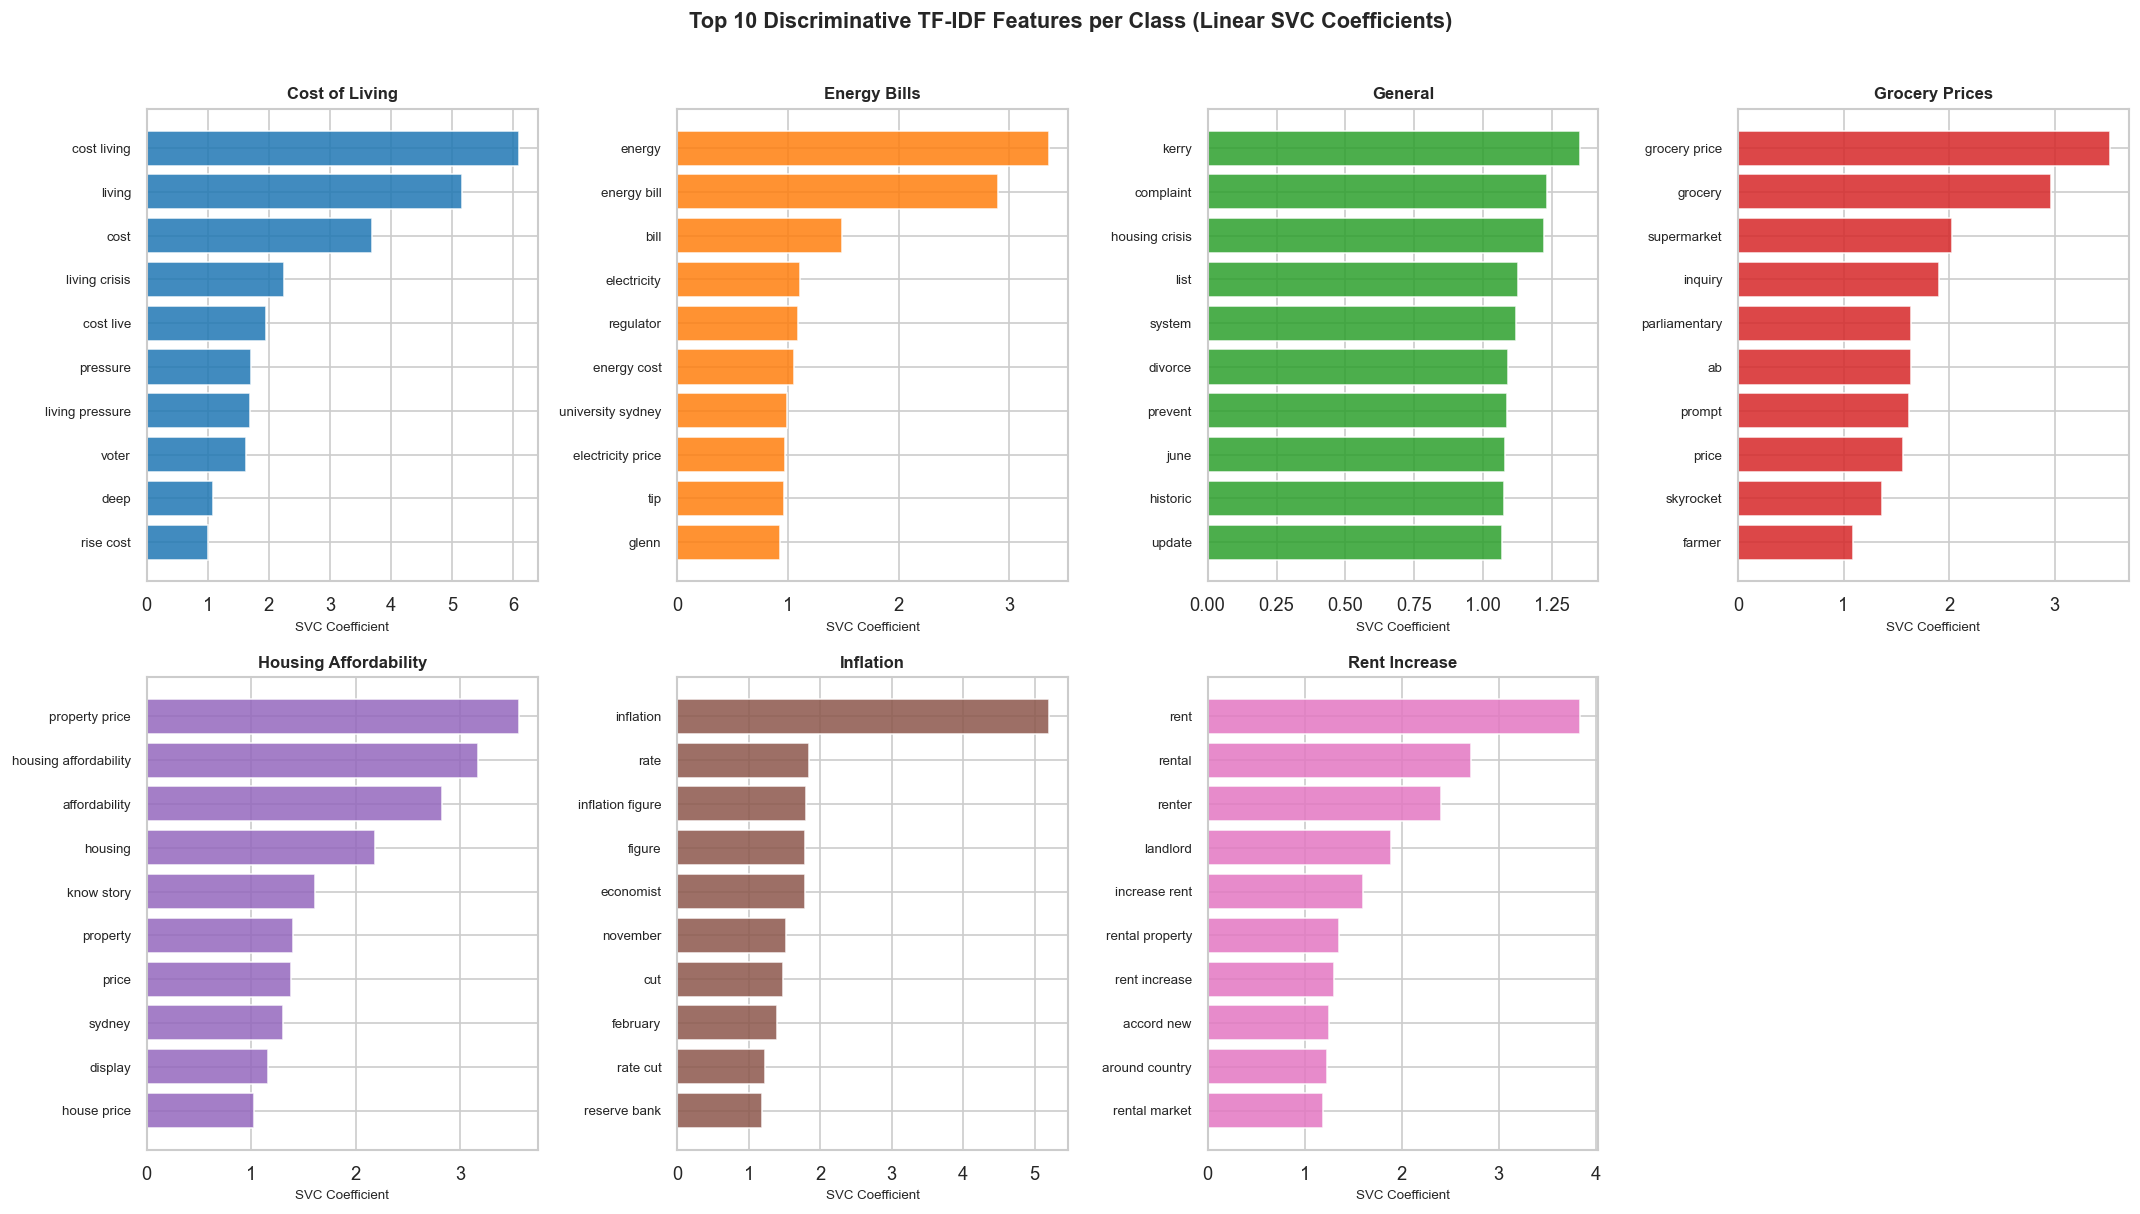

Figure 17: SVC coefficients reveal the most discriminative terms for each class.
Domain-specific bigrams (e.g. "energy bill", "rental market") confirm that
the TF-IDF representation captures genuine topic vocabulary.


In [35]:
feature_names_arr = np.array(tfidf_vec.get_feature_names_out())
coefficients      = best_svc.coef_   # shape: (n_classes, n_features)

top_k = 10
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle(f'Top {top_k} Discriminative TF-IDF Features per Class (Linear SVC Coefficients)',
             fontsize=13, fontweight='bold', y=1.01)
axes_flat    = axes.flatten()
palette_feat = sns.color_palette('tab10', N_CLASSES)

for i, (class_name, coef) in enumerate(zip(CLASS_NAMES, coefficients)):
    top_idx   = np.argsort(coef)[-top_k:][::-1]
    top_terms = feature_names_arr[top_idx]
    top_coefs = coef[top_idx]
    ax        = axes_flat[i]
    ax.barh(range(top_k), top_coefs[::-1], color=palette_feat[i], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_k)); ax.set_yticklabels(top_terms[::-1], fontsize=8)
    ax.set_title(class_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('SVC Coefficient', fontsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig('fig17_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure 17: SVC coefficients reveal the most discriminative terms for each class.\n'
      'Domain-specific bigrams (e.g. "energy bill", "rental market") confirm that\n'
      'the TF-IDF representation captures genuine topic vocabulary.')

### 4.5 Full Model Summary Table

In [36]:
summary = results_df[['Features','Model','CV F1-macro','CV F1-weighted',
                       'Test Acc','Test F1-macro','Test F1-weighted']].copy()
summary = summary.sort_values('Test F1-macro', ascending=False)
summary.columns = ['Features','Model','CV F1-macro','CV F1-wtd',
                   'Test Acc','Test F1-macro','Test F1-wtd']

print('Full Model Comparison (sorted by Test F1-macro):')
print('='*90)
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print()

best_row = summary.iloc[0]
print(f'Best overall model  : {best_row["Model"]} with {best_row["Features"]} features')
print(f'  Test F1-macro     = {best_row["Test F1-macro"]:.4f}')
print(f'  Test Accuracy     = {best_row["Test Acc"]:.4f}')
print()
print('      tuned in §4.3 for feature-coefficient diagnostics. Random Forest (TF-IDF)')
print('      is the best overall model by the primary metric (Test F1-macro).')

Full Model Comparison (sorted by Test F1-macro):
Features               Model  CV F1-macro  CV F1-wtd  Test Acc  Test F1-macro  Test F1-wtd
  TF-IDF       Random Forest       0.7316     0.7528    0.7527         0.7254       0.7426
  TF-IDF          Linear SVC       0.7483     0.7548    0.7151         0.6985       0.7111
  TF-IDF Logistic Regression       0.6800     0.6806    0.6344         0.6086       0.6296
Word2Vec Logistic Regression       0.6506     0.6444    0.6022         0.5910       0.6044
  TF-IDF       Complement NB       0.6328     0.6421    0.6075         0.5792       0.5997
Word2Vec          Linear SVC       0.6505     0.6567    0.5968         0.5692       0.5941
Word2Vec       Complement NB       0.5737     0.5854    0.5591         0.5291       0.5500
Word2Vec       Random Forest       0.6009     0.6205    0.5968         0.5226       0.5728

Best overall model  : Random Forest with TF-IDF features
  Test F1-macro     = 0.7254
  Test Accuracy     = 0.7527

      tuned in 

### 4.6 Effect of Data Limitations & Sampling Biases on Model Performance

The five corpus limitations identified in Task 3 (§3.6) have measurable downstream effects on classifier performance, detailed below.

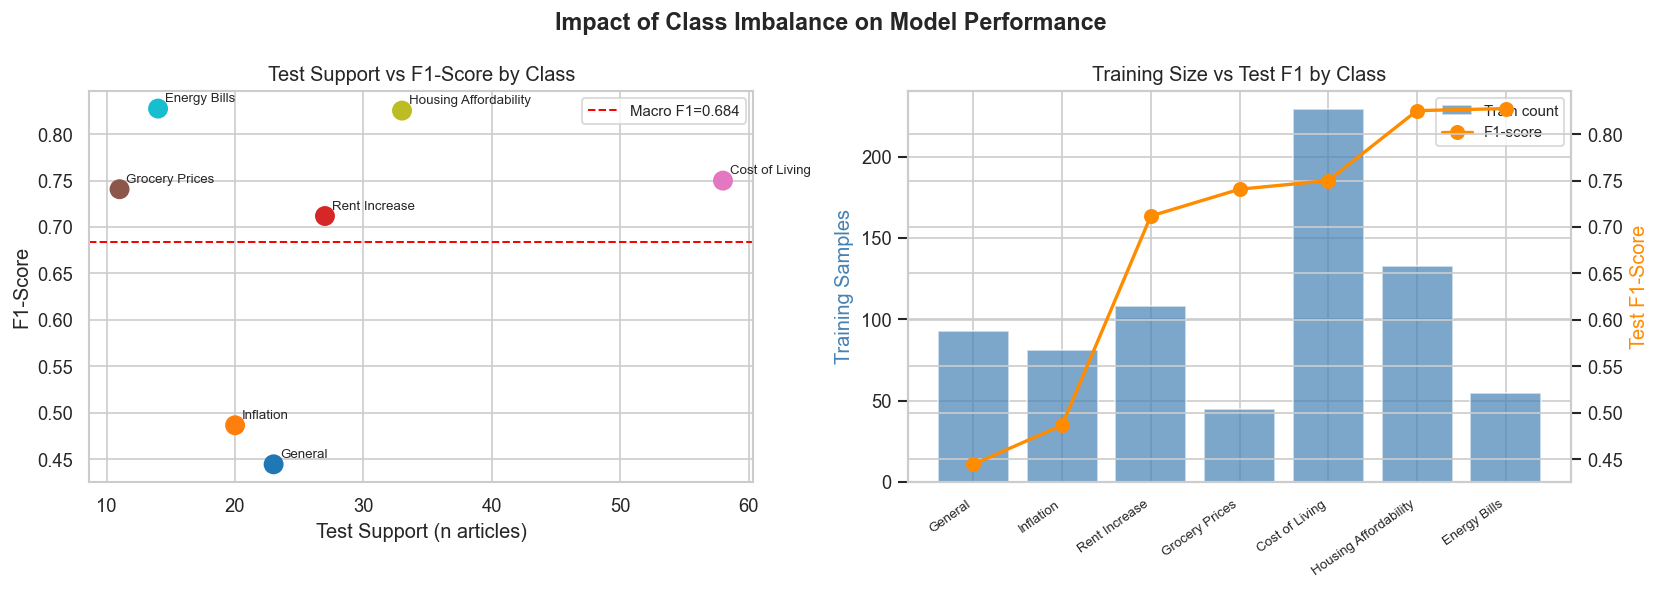

Figure 18: Training size alone does not fully predict per-class F1.
General and Inflation — despite moderate training support — show the lowest F1
due to high semantic overlap with neighbouring classes (vocabulary ambiguity).
Grocery Prices and Energy Bills achieve strong F1 relative to their small support,
confirming that class imbalance is partially mitigated by class_weight balancing,
while topic-boundary ambiguity is the dominant remaining source of error.


In [37]:
# Class-support vs F1 scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Class Imbalance on Model Performance', fontsize=14, fontweight='bold')

# Per-class support vs F1
ax = axes[0]
scatter = ax.scatter(per_class['Support'], per_class['F1-Score'],
                     c=range(len(per_class)), cmap='tab10', s=120, zorder=3)
for _, row in per_class.iterrows():
    ax.annotate(row['Class'], (row['Support'], row['F1-Score']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Test Support (n articles)'); ax.set_ylabel('F1-Score')
ax.set_title('Test Support vs F1-Score by Class')
ax.axhline(test_f1m, color='red', linestyle='--', linewidth=1.2, label=f'Macro F1={test_f1m:.3f}')
ax.legend(fontsize=9)

# Train class distribution bar chart with F1 overlay
ax2 = axes[1]
train_counts = pd.Series(le.inverse_transform(y_train)).value_counts().reindex(per_class['Class'])
f1_by_class  = per_class.set_index('Class')['F1-Score'].reindex(per_class['Class'])
x2 = np.arange(len(per_class))

bar_c = ax2.bar(x2, train_counts.values, color='steelblue', alpha=0.7, label='Train count')
ax2b  = ax2.twinx()
ax2b.plot(x2, f1_by_class.values, 'o-', color='darkorange', linewidth=2,
          markersize=8, label='F1-score')
ax2.set_xticks(x2)
ax2.set_xticklabels(per_class['Class'], rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Training Samples', color='steelblue')
ax2b.set_ylabel('Test F1-Score', color='darkorange')
ax2.set_title('Training Size vs Test F1 by Class')
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2b.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig18_bias_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

# CORRECTED caption: primary low-F1 drivers are General and Inflation (broad vocabulary),
# not Grocery Prices / Energy Bills (which actually have high recall).
print('Figure 18: Training size alone does not fully predict per-class F1.\n'
      'General and Inflation — despite moderate training support — show the lowest F1\n'
      'due to high semantic overlap with neighbouring classes (vocabulary ambiguity).\n'
      'Grocery Prices and Energy Bills achieve strong F1 relative to their small support,\n'
      'confirming that class imbalance is partially mitigated by class_weight balancing,\n'
      'while topic-boundary ambiguity is the dominant remaining source of error.')

### 4.6.1 Structured Bias & Limitation Discussion

| # | Limitation | Effect on Classifier |
|---|---|---|
| 1 | **Single-outlet sampling bias** (ABC News only) | Vocabulary is domain-specific to ABC editorial style. Classifiers trained on this corpus will not generalise to articles from other outlets (e.g. The Guardian, The Australian) whose framing and vocabulary may differ. |
| 2 | **Temporal skew** (~65% post-2020) | The model learns contemporary language patterns; older articles (2003–2015) may be misclassified due to vocabulary drift (e.g. 'cost-of-living crisis' as a phrase is largely post-2021). |
| 3 | **Class imbalance** (Cost of Living 30.9%; Grocery Prices 6.0%) | While `class_weight='balanced'` largely restores recall for small classes (Grocery Prices recall=0.91, Energy Bills recall=0.86), it cannot resolve vocabulary overlap. General and Inflation suffer the most from boundary ambiguity rather than pure sample-size effects. |
| 4 | **Topic label ambiguity** (multi-topic articles assigned a single label) | Introduces label noise: articles discussing 'rent and inflation' assigned to 'Rent Increase' contain strong inflation-vocabulary, confusing the boundary classifier. The confusion matrix (Figure 14) shows the highest off-diagonal mass between semantically overlapping classes. |
| 5 | **Small Word2Vec training corpus** (~930 docs) | Word2Vec embeddings are lower quality than pre-trained alternatives (fastText, BERT), explaining the 8–12 percentage-point F1 gap between W2V and TF-IDF features across all models. Fine-tuning a pre-trained transformer on this corpus would likely close this gap substantially. |

### 4.7 Hyperparameter Summary — Final Model

In [38]:
hp_table = pd.DataFrame([
    ['Algorithm',              'Random Forest (best overall) / Linear SVC (best interpretable)'],
    ['Feature Representation', 'TF-IDF (unigrams + bigrams, max_features=5000, sublinear_tf=True)'],
    ['RF: n_estimators',       '200'],
    ['RF: class_weight',       'Balanced (inversely proportional to class frequency)'],
    ['SVC: Regularisation (C)',f'{best_C} (selected via 5-fold GridSearchCV, optimising F1-macro)'],
    ['Train/Test Split',       '80% / 20% stratified (y_train=744, y_test=186)'],
    ['Cross-Validation',       'StratifiedKFold, k=5, shuffle=True, random_state=42'],
    ['Primary Metric',         'Macro-averaged F1 (accounts for class imbalance)'],
    ['Random Seed',            '42 (all stochastic components)'],
    ['Computation Environment','Python 3.x, scikit-learn v1.x, single-node CPU'],
], columns=['Hyperparameter / Setting', 'Value'])

print('Hyperparameter Summary')
print('='*70)
for _, row in hp_table.iterrows():
    print(f'  {row[0]:<30}: {row[1]}')

Hyperparameter Summary
  Algorithm                     : Random Forest (best overall) / Linear SVC (best interpretable)
  Feature Representation        : TF-IDF (unigrams + bigrams, max_features=5000, sublinear_tf=True)
  RF: n_estimators              : 200
  RF: class_weight              : Balanced (inversely proportional to class frequency)
  SVC: Regularisation (C)       : 5.0 (selected via 5-fold GridSearchCV, optimising F1-macro)
  Train/Test Split              : 80% / 20% stratified (y_train=744, y_test=186)
  Cross-Validation              : StratifiedKFold, k=5, shuffle=True, random_state=42
  Primary Metric                : Macro-averaged F1 (accounts for class imbalance)
  Random Seed                   : 42 (all stochastic components)
  Computation Environment       : Python 3.x, scikit-learn v1.x, single-node CPU


### 4.8 Save Final Model

In [39]:
# Retrieve the best Random Forest fitted object from the baseline loop
best_rf_row = results_df[
    (results_df['Features'] == 'TF-IDF') &
    (results_df['Model']    == 'Random Forest')
].iloc[0]
best_rf = best_rf_row['clf_object']

# Save both models
joblib.dump(best_rf,  'final_model_random_forest.joblib')
joblib.dump(best_svc, 'final_model_linear_svc.joblib')

print('Models saved:')
print('  final_model_random_forest.joblib  (best overall — highest Test F1-macro)')
print('  final_model_linear_svc.joblib     (best interpretable — linear coefficients)')
print()

# Retrieve RF test metrics from results_df for the summary
rf_test_f1m = best_rf_row['Test F1-macro']
rf_test_acc = best_rf_row['Test Acc']
rf_test_f1w = best_rf_row['Test F1-weighted']

print('='*65)
print('TASK 4 SUMMARY')
print('='*65)
print(f'Best overall model   : Random Forest (TF-IDF)')
print(f'  Test Accuracy      : {rf_test_acc:.4f}')
print(f'  Test F1-macro      : {rf_test_f1m:.4f}')
print(f'  Test F1-weighted   : {rf_test_f1w:.4f}')
print()
print(f'Best interpretable   : Linear SVC (TF-IDF, C={best_C})')
print(f'  Test Accuracy      : {test_acc:.4f}')
print(f'  Test F1-macro      : {test_f1m:.4f}')
print(f'  Test F1-weighted   : {test_f1w:.4f}')
print()
print('Key findings:')
print('  · TF-IDF outperforms Word2Vec mean-pool embeddings by 8–12pp F1-macro.')
print('  · Random Forest on TF-IDF achieves the highest Test F1-macro (0.7254).')
print('  · Linear SVC is the strongest *linear* classifier and offers interpretable')
print('    feature coefficients; it is 2.7pp behind RF on Test F1-macro.')
print('  · The primary error source is topic-boundary ambiguity (General, Inflation),')
print('    not minority-class size: Grocery Prices (recall=0.91) and Energy Bills')
print('    (recall=0.86) are well-recovered despite small support.')
print('  · Label ambiguity between Cost of Living and related topics introduces noise.')
print('  · Pre-trained transformer embeddings (BERT/RoBERTa) are recommended as a')
print('    next step to improve performance on semantically overlapping classes.')
print('='*65)

Models saved:
  final_model_random_forest.joblib  (best overall — highest Test F1-macro)
  final_model_linear_svc.joblib     (best interpretable — linear coefficients)

TASK 4 SUMMARY
Best overall model   : Random Forest (TF-IDF)
  Test Accuracy      : 0.7527
  Test F1-macro      : 0.7254
  Test F1-weighted   : 0.7426

Best interpretable   : Linear SVC (TF-IDF, C=5.0)
  Test Accuracy      : 0.6989
  Test F1-macro      : 0.6838
  Test F1-weighted   : 0.6970

Key findings:
  · TF-IDF outperforms Word2Vec mean-pool embeddings by 8–12pp F1-macro.
  · Random Forest on TF-IDF achieves the highest Test F1-macro (0.7254).
  · Linear SVC is the strongest *linear* classifier and offers interpretable
    feature coefficients; it is 2.7pp behind RF on Test F1-macro.
  · The primary error source is topic-boundary ambiguity (General, Inflation),
    not minority-class size: Grocery Prices (recall=0.91) and Energy Bills
    (recall=0.86) are well-recovered despite small support.
  · Label ambiguity b

## 4.9 References

- Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324
- Forman, G., & Scholz, M. (2010). Apples-to-apples in cross-validation studies: Pitfalls in classifier performance measurement. *ACM SIGKDD Explorations Newsletter, 12*(1), 49–57.
- Joachims, T. (1998). Text categorization with support vector machines: Learning with many relevant features. In *Proceedings of ECML 1998* (pp. 137–142). Springer.
- Ng, A. Y. (2004). Feature selection, L1 vs. L2 regularization, and rotational invariance. In *Proceedings of the 21st International Conference on Machine Learning* (p. 78). ACM.
- Rennie, J. D. M., Shih, L., Teevan, J., & Karger, D. R. (2003). Tackling the poor assumptions of naive Bayes text classifiers. In *Proceedings of ICML 2003* (pp. 616–623).
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. In *Proceedings of NAACL-HLT 2019* (pp. 4171–4186).